In [116]:
import numpy as np
import scipy.sparse as sp
import tensorflow as tf
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout,Input,Reshape,BatchNormalization
from tensorflow.keras.losses import CategoricalCrossentropy, BinaryCrossentropy
from tensorflow.keras.metrics import categorical_accuracy, binary_accuracy
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.regularizers import L1, L2, l2
from tensorflow.keras import layers

import spektral
from spektral.data import MixedLoader
from spektral.data import Dataset, DisjointLoader, Graph
from spektral.layers import GCSConv, GlobalAvgPool, GATConv, DiffPool, GlobalAttentionPool
from spektral.layers.pooling import TopKPool
from spektral.transforms.normalize_adj import NormalizeAdj
from spektral.utils.sparse import sp_matrix_to_sp_tensor
import tensorflow.keras.backend as K

In [117]:
class MyDataset(Dataset):
    """
    """
    def __init__(self, datafromnpzfile, **kwargs):
        self.a=None
        self.file=datafromnpzfile
        self.x=datafromnpzfile['x']
        self.y = datafromnpzfile['y']
        self.info = datafromnpzfile['info']
        self.cols=datafromnpzfile['cols']
        self.n=self.x.shape[0]
        super().__init__(**kwargs)
    def read(self):
        self.a=sp.csr_matrix(self.file['pathway_a'])
        graph=[]
        for i in range(self.n):
            x=self.x[i]
            y=self.y[i]
            graph.append(Graph(x=x,y=y))
        # We must return a list of Graph objects
        return graph

In [118]:
import os
import re
import pandas as pd


# data_dir = os.path.dirname(__file__)
class GMT():
    # genes_cols : start reading genes from genes_col(default 1, it can be 2 e.g. if an information col is added after the pathway col)
    # pathway col is considered to be the first column (0)
    def load_data(self, filename, genes_col=1, pathway_col=0):

        data_dict_list = []
        with open(filename) as gmt:

            data_list = gmt.readlines()

            # print data_list[0]
            for row in data_list:
                genes = row.strip().split('\t')
                genes = [re.sub('_copy.*', '', g) for g in genes]
                genes = [re.sub('\\n.*', '', g) for g in genes]
                for gene in genes[genes_col:]:
                    pathway = genes[pathway_col]
                    dict = {'group': pathway, 'gene': gene}
                    data_dict_list.append(dict)

        df = pd.DataFrame(data_dict_list)
        # print df.head()

        return df

    def load_data_dict(self, filename):

        data_dict_list = []
        dict = {}
        with open(os.path.join(data_dir, filename)) as gmt:
            data_list = gmt.readlines()

            # print data_list[0]
            for row in data_list:
                genes = row.split('\t')
                dict[genes[0]] = genes[2:]

        return dict

    def write_dict_to_file(self, dict, filename):
        lines = []
        with open(filename, 'w') as gmt:
            for k in dict:
                str1 = '	'.join(str(e) for e in dict[k])
                line = str(k) + '	' + str1 + '\n'
                lines.append(line)
            gmt.writelines(lines)
        return

    def __init__(self):

        return


In [119]:
import logging
import numpy as np
import pandas as pd

def get_KEGG_map(input_list, filename='c2.cp.kegg.v6.1.symbols.gmt', genes_col=1, shuffle_genes=False):
    '''
    :param input_list: list of inputs under consideration (e.g. genes)
    :param filename: a gmt formated file e.g. pathway1 gene1 gene2 gene3
#                                     pathway2 gene4 gene5 gene6
    :param genes_col: the start index of the gene columns
    :param shuffle_genes: {True, False}
    :return: dataframe with rows =genes and columns = pathways values = 1 or 0 based on the membership of certain gene in the corresponding pathway
    '''
    d = GMT()
    df = d.load_data(filename, genes_col)
    df['value'] = 1
    mapp = pd.pivot_table(df, values='value', index='gene', columns='group', aggfunc=np.sum)
    mapp = mapp.fillna(0)
    cols_df = pd.DataFrame(index=input_list)
    mapp = cols_df.merge(mapp, right_index=True, left_index=True, how='left')
    mapp = mapp.fillna(0)
    genes = mapp.index
    pathways = mapp.columns
    mapp = mapp.values

    if shuffle_genes:
        logging.info('shuffling')
        ones_ratio = np.sum(mapp) / np.prod(mapp.shape)
        logging.info('ones_ratio {}'.format(ones_ratio))
        mapp = np.random.choice([0, 1], size=mapp.shape, p=[1 - ones_ratio, ones_ratio])
        logging.info('random map ones_ratio {}'.format(ones_ratio))
    return mapp, genes, pathways


In [120]:
import numpy as np
from tensorflow.keras.layers import Layer
from tensorflow.keras import regularizers
from tensorflow.keras.initializers import glorot_uniform, Initializer
from tensorflow.keras import activations
from tensorflow.keras import initializers, constraints
from tensorflow.keras.regularizers import Regularizer

class SparseTF(Layer):
    def __init__(self, units, map=None, nonzero_ind=None, kernel_initializer='glorot_uniform', W_regularizer=None,
                 activation='tanh', use_bias=True,
                 bias_initializer='zeros', bias_regularizer=None, kernel_constraint=None, bias_constraint=None,
                 **kwargs):
        self.units = units
        self.activation = activation
        self.map = map
        self.nonzero_ind = nonzero_ind
        self.use_bias = use_bias
        self.kernel_initializer = initializers.get(kernel_initializer)
        self.kernel_regularizer = regularizers.get(W_regularizer)
        self.bias_initializer = initializers.get(bias_initializer)
        self.bias_regularizer = regularizers.get(bias_regularizer)
        self.activation_fn = activations.get(activation)
        self.kernel_constraint = constraints.get(kernel_constraint)
        self.bias_constraint = constraints.get(bias_constraint)
        super(SparseTF, self).__init__(**kwargs)

    def build(self, input_shape):
        input_dim = input_shape[1]
        # random sparse constarints on the weights
        # if self.map is None:
        #     mapp = np.random.rand(input_dim, self.units)
        #     mapp = mapp > 0.9
        #     mapp = mapp.astype(np.float32)
        #     self.map = mapp
        # else:
        if not self.map is None:
            self.map = self.map.astype(np.float32)

        # can be initialized directly from (map) or using a loaded nonzero_ind (useful for cloning models or create from config)
        if self.nonzero_ind is None:
            nonzero_ind = np.array(np.nonzero(self.map)).T
            self.nonzero_ind = nonzero_ind

        self.kernel_shape = (input_dim, self.units)
        # sA = sparse.csr_matrix(self.map)
        # self.sA=sA.astype(np.float32)
        # self.kernel_sparse = tf.SparseTensor(self.nonzero_ind, sA.data, sA.shape)

        # self.kernel_shape = (input_dim, self.units)
        # sA = sparse.csr_matrix(self.map)
        # self.sA=sA.astype(np.float32)
        # self.kernel_sparse = tf.SparseTensor(self.nonzero_ind, sA.data, sA.shape)
        # self.kernel_dense = tf.Variable(self.map)

        nonzero_count = self.nonzero_ind.shape[0]

        # initializer = initializers.get('uniform')
        # print 'nonzero_count', nonzero_count
        # self.kernel_vector = K.variable(initializer((nonzero_count,)), dtype=K.floatx(), name='kernel' )

        self.kernel_vector = self.add_weight(name='kernel_vector',
                                             shape=(nonzero_count,),
                                             initializer=self.kernel_initializer,
                                             regularizer=self.kernel_regularizer,
                                             trainable=True, constraint=self.kernel_constraint)
        # self.kernel = tf.scatter_nd(self.nonzero_ind, self.kernel_vector, self.kernel_shape, name='kernel')
        # --------
        # init = np.random.rand(input_shape[1], self.units).astype( np.float32)
        # sA = sparse.csr_matrix(init)
        # self.kernel = K.variable(sA, dtype=K.floatx(), name= 'kernel',)
        # self.kernel_vector = K.variable(init, dtype=K.floatx(), name= 'kernel',)

        # print self.kernel.values
        # ind = np.array(np.nonzero(init))
        # stf = tf.SparseTensor(ind.T, sA.data, sA.shape)
        # print stf.dtype
        # print init.shape
        # # self.kernel = stf
        # self.kernel = tf.keras.backend.variable(stf, dtype='SparseTensor', name='kernel')
        # print self.kernel.values

        if self.use_bias:
            self.bias = self.add_weight(shape=(self.units,),
                                        initializer=self.bias_initializer,
                                        name='bias',
                                        regularizer=self.bias_regularizer,
                                        constraint=self.bias_constraint)
        else:
            self.bias = None

        super(SparseTF, self).build(input_shape)  # Be sure to call this at the end
        # self.trainable_weights = [self.kernel_vector]

    def call(self, inputs):
        # print self.kernel_vector.shape, inputs.shape
        # print self.kernel_shape, self.kernel_vector
        # print self.nonzero_ind
        # kernel_sparse= tf.S parseTensor(self.nonzero_ind, self.kernel_vector, self.kernel_shape)
        # pr = cProfile.Profile()
        # pr.enable()

        # print self.kernel_vector
        # self.kernel_sparse._values = self.kernel_vector
        tt = tf.scatter_nd(self.nonzero_ind, self.kernel_vector, self.kernel_shape)
        # print tt
        # update  = self.kernel_vector
        # tt= tf.scatter_add(self.kernel_dense, self.nonzero_ind, update)
        # tt= self.kernel_dense
        # tt[self.nonzero_ind].assign( self.kernel_vector)
        # self.kernel_dense[self.nonzero_ind] = self.kernel_vector
        # tt= tf.sparse.transpose(self.kernel_sparse)
        # output = tf.sparse.matmul(tt, tf.transpose(inputs ))
        # output = tf.matmul(tt, inputs )
        output = K.dot(inputs, tt)
        # pr.disable()
        # pr.print_stats(sort="time")
        # return tf.transpose(output)
        if self.use_bias:
            output = K.bias_add(output, self.bias)
        if self.activation_fn is not None:
            output = self.activation_fn(output)

        return output

    def get_config(self):
        config = {
            'units': self.units,
            'activation': self.activation,
            # 'kernel_shape': self.kernel_shape,
            'use_bias': self.use_bias,
            'nonzero_ind': np.array(self.nonzero_ind),
            # 'kernel_initializer': initializers.serialize(self.kernel_initializer),
            # 'kernel_regularizer': regularizers.serialize(self.kernel_regularizer),
            'bias_initializer': initializers.serialize(self.bias_initializer),
            'bias_regularizer': regularizers.serialize(self.bias_regularizer),

            'kernel_initializer': initializers.serialize(self.kernel_initializer),
            'W_regularizer': regularizers.serialize(self.kernel_regularizer),

        }
        base_config = super(SparseTF, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

    # def call(self, inputs):
    #     print self.kernel.shape, inputs.shape
    #     tt= tf.sparse.transpose(self.kernel)
    #     output = tf.sparse.matmul(tt, tf.transpose(inputs ))
    #     return tf.transpose(output)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.units)

    # def get_weights(self):
    #
    #     return [self.kernel_vector, self.bias]

In [121]:
genes=[]
with open('./genelist_8080.txt','r') as reader:
    line = reader.readline().strip()
    while line != '':  # The EOF char is an empty string
        genes.append(line)
        line = reader.readline().strip()
genes=np.array(genes)

In [122]:
mapp, genes, pathways = get_KEGG_map(genes, filename='./Kegg/human_KeggPathwayGene.gmt')
n_genes, n_pathways = mapp.shape



def build_model(mapp, n_genes, n_pathways, mapping_l1_reg = 2.5e-3, gat1_l2_reg = 2.5e-3, gat2_l2_reg = 2.5e-3, pool_l1_reg = 2.5e-3, x_dropRate = 0.3, 
                gat1_dropRate = 0.3, gat2_dropRate = 0.3, gat1_channel = 3, gat1_nhead = 3, gat2_channel = 6, pool_channel = 12, dense_channel = 6):
    x_in = Input(shape=(n_genes,))
    x_drop1 = Dropout(x_dropRate)(x_in)
    mapping_layer = SparseTF(n_pathways, mapp, activation='elu', W_regularizer=L1(mapping_l1_reg),
                                name='mapping', kernel_initializer='glorot_uniform',
                                use_bias=True)
    layer2_output = mapping_layer(x_drop1)
    layer2_res=Reshape([n_pathways,1])(layer2_output)
    a_in = Input(shape=(n_pathways,),sparse=True)
    x_1 = GATConv(
        gat1_channel,
        attn_heads=gat1_nhead,
        concat_heads=False,
        activation="tanh",
        return_attn_coef=False,
        dropout_rate=gat1_dropRate,
        kernel_regularizer=l2(gat1_l2_reg),
        attn_kernel_regularizer=l2(gat1_l2_reg),
        bias_regularizer=l2(gat1_l2_reg),
        bias_initializer='glorot_uniform',
    )([layer2_res, a_in])
    x1bn = layers.BatchNormalization()(x_1)
    x_2,att = GATConv(
        gat2_channel,
        attn_heads=1,
        concat_heads=True,
        activation="tanh",
        return_attn_coef=True,
        dropout_rate=gat2_dropRate,
        kernel_regularizer=l2(gat2_l2_reg),
        attn_kernel_regularizer=l2(gat2_l2_reg),
        bias_regularizer=l2(gat2_l2_reg),
        bias_initializer='glorot_uniform',
    )([x1bn, a_in])
    x2bn = layers.BatchNormalization()(x_2)
    attpool=GlobalAttentionPool(pool_channel, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=L1(pool_l1_reg))(x2bn)
    x_fc1 = Dense(dense_channel, activation="elu")(attpool)
    output = Dense(2, activation="softmax")(x_fc1)  # MNIST has 10 classes
    model = Model(inputs=[x_in, a_in], outputs=[output,x2bn, att])
    #optimizer = Adam(lr=1e-1)
    return model



###  random parameter  ###
mapping_l1_reg = 2.5e-3
gat1_l2_reg = 2.5e-3
gat2_l2_reg = 2.5e-3
pool_l1_reg = 2.5e-3
x_dropRate = 0.5
gat1_dropRate = 0.4
gat2_dropRate = 0.4
gat1_channel = 4
gat1_nhead = 4
gat2_channel = 4
pool_channel = 8
dense_channel = 8


model=build_model(mapp, n_genes, n_pathways, mapping_l1_reg, gat1_l2_reg, gat2_l2_reg, pool_l1_reg, x_dropRate, 
                    gat1_dropRate, gat2_dropRate, gat1_channel, gat1_nhead, gat2_channel, pool_channel, dense_channel)



model.summary()

Model: "model_7"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_15 (InputLayer)           [(None, 8080)]       0                                            
__________________________________________________________________________________________________
dropout_7 (Dropout)             (None, 8080)         0           input_15[0][0]                   
__________________________________________________________________________________________________
mapping (SparseTF)              (None, 344)          33514       dropout_7[0][0]                  
__________________________________________________________________________________________________
reshape_7 (Reshape)             (None, 344, 1)       0           mapping[0][0]                    
____________________________________________________________________________________________

In [123]:
from scipy.special import softmax

def get_gene_importance(model,pathway_ind, mapp,weight_folder,weight_presuffix,weight_metric):
    weights=np.zeros([5,33170])
    for fold in range(5):
        model.load_weights(weight_folder+weight_presuffix+str(fold)+'/_'+weight_metric)
        weights[fold,:]=np.array(model.weights[0])
    weights=np.mean(weights,axis=0)
    # model.load_weights("../tem/SKCM_bsp_randParam_"+str(fold)+"/_va_f1")
    # weights=model.weights[0]
    nonzero_ind=np.array(np.nonzero(mapp)).T
    weight_matrix=np.zeros([mapp.shape[0],mapp.shape[1]])
    for i in range(nonzero_ind.shape[0]):
        x=nonzero_ind[i,0]
        y=nonzero_ind[i,1]
        weight_matrix[x,y] = weights[i]
    pathway_vector=weight_matrix[:,pathway_ind]
    geneind=[]
    value=[]
    for i in range(mapp.shape[0]):
        if pathway_vector[i]!=0:
            geneind.append(i)
            value.append(pathway_vector[i])
    m=softmax(value)
    geneind2perc={}
    for j in range(len(value)):
        geneind2perc[geneind[j]]=m[j]
    # s=sum(abs(pathway_vector))
    # geneind2perc={}
    # for i in range(mapp.shape[0]):
    #     if pathway_vector[i]!=0:
    #         geneind2perc[i]=abs(pathway_vector[i])/s
    return geneind2perc
    



In [124]:
def get_pathway_relation(datafromnpz,model,weight_folder,weight_presuffix,weight_metric):
    
    x=datafromnpz['x']
    y=datafromnpz['y']
    info=datafromnpz['info']
    cols=datafromnpz['cols']
    a=datafromnpz['pathway_a']
    results=np.zeros([5,y.shape[0],344,344])
    for fold in range(5):
        model.load_weights(weight_folder+weight_presuffix+str(fold)+'/_'+weight_metric)
        results[fold,:,:,:] = np.array(model([x,a],training=False)[2]).reshape(y.shape[0],344,344)
    results_mean = np.mean(results, axis=0)
    return results_mean

In [125]:


def get_pathway_importance(datafromnpz,model,weight_folder,weight_presuffix,weight_metric):
    x=datafromnpz['x']
    y=datafromnpz['y']
    info=datafromnpz['info']
    cols=datafromnpz['cols']
    a=datafromnpz['pathway_a']
    results=np.zeros([5,y.shape[0],344,4])
    weights=np.zeros([5,4,8])
    predictions=np.zeros([5,y.shape[0],y.shape[1]])
    for fold in range(5):
        model.load_weights(weight_folder+weight_presuffix+str(fold)+'/_'+weight_metric)
        results[fold,:,:,:] = np.array(model([x,a],training=False)[1])
        weights[fold,:,:]=np.array(model.weights[20])
        prediction = model([x,a],training=False)[0]
        predictions[fold,:,:]=prediction
    predictions_mean = np.mean(predictions, axis=0)
    results_mean = np.mean(results, axis=0)
    print(results_mean.shape)
    weights_mean = np.mean(weights, axis=0)
    print(weights_mean.shape)
    att=np.matmul(results_mean, weights_mean)  
    att_pathway=np.mean(att,axis=2)
    m=softmax(att_pathway,axis=1)
    return m,predictions_mean
        

In [11]:
# suvival
# within study evaluation

from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
import numpy as np
import sklearn
import random
random.seed(996)


###  random parameter  ###
mapping_l1_reg = 2.5e-3
gat1_l2_reg = 2.5e-3
gat2_l2_reg = 2.5e-3
pool_l1_reg = 2.5e-3
x_dropRate = 0.5
gat1_dropRate = 0.4
gat2_dropRate = 0.4
gat1_channel = 4
gat1_nhead = 4
gat2_channel = 4
pool_channel = 8
dense_channel = 8
batch_size = 10  # Batch size
hyperParams_random = np.array([
[2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.5,0.4,0.4,4,4,4,8,8,10],
[2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.5,0.4,0.4,4,4,4,8,8,10],
[2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.5,0.4,0.4,4,4,4,8,8,10],
[2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.5,0.4,0.4,4,4,4,8,8,10],
[2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.5,0.4,0.4,4,4,4,8,8,10]
])

# hyperParams_random = np.array([
# [2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.3,0.3,0.3,3,3,6,12,6,5],
# [2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.3,0.3,0.3,3,3,6,12,6,5],
# [2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.3,0.3,0.3,3,3,6,12,6,5],
# [2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.3,0.3,0.3,3,3,6,12,6,5],
# [2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.3,0.3,0.3,3,3,6,12,6,5]
# ])

###  opti IMvigor ROC  ###
hyperParams_IMvigor=np.array([
[0.00675190391336071,0.005493762552723812,0.004519753059018278,0.0045195975667924534,0.46362793709225414,0.48819564127373993,0.2649679082634909,7,9,5,25,11,9],
[0.004753781661814064,0.00984774073557786,0.0048767374957450465,0.0007873736162618307,0.3194759952137326,0.30398181418512144,0.4979219375485108,3,3,10,12,9,5],
[0.0071387418189729525,0.005222498035643917,0.0027004909388650775,0.0009363385112361626,0.29024065711708774,0.14865279095047879,0.15748988511469506,3,6,6,18,13,6],
[0.003968517903566386,0.004080120823919732,0.0042587618179442885,0.009978974683794863,0.20088388535107163,0.3332139513019352,0.10333163146773422,4,4,12,5,5,3],
[0.0018638222878056294,0.0029886076626495254,0.0040239676839539254,0.003992625256227416,0.18392455882921968,0.23979599005221788,0.2249788516873279,3,5,15,13,7,4]
])

###  opti Liu ROC  ###
hyperParams_Liu=np.array([
[0.009161283552587185,0.0086139933888295,0.0010692657989040144,0.003913069210703885,0.3748124481558166,0.49048942098340775,0.4925881321925005,4.0,9.0,8.0,14.0,14.0,3],
[0.009161283552587185,0.0086139933888295,0.0010692657989040144,0.003913069210703885,0.3748124481558166,0.49048942098340775,0.4925881321925005,4.0,9.0,8.0,14.0,14.0,3],
[0.009161283552587185,0.0086139933888295,0.0010692657989040144,0.003913069210703885,0.3748124481558166,0.49048942098340775,0.4925881321925005,4.0,9.0,8.0,14.0,14.0,3],
[0.009161283552587185,0.0086139933888295,0.0010692657989040144,0.003913069210703885,0.3748124481558166,0.49048942098340775,0.4925881321925005,4.0,9.0,8.0,14.0,14.0,3],
[0.009161283552587185,0.0086139933888295,0.0010692657989040144,0.003913069210703885,0.3748124481558166,0.49048942098340775,0.4925881321925005,4.0,9.0,8.0,14.0,14.0,3]
])



model=build_model(mapp, n_genes, n_pathways, mapping_l1_reg, gat1_l2_reg, gat2_l2_reg, pool_l1_reg, x_dropRate, 
                    gat1_dropRate, gat2_dropRate, gat1_channel, gat1_nhead, gat2_channel, pool_channel, dense_channel)



random.seed(996)

def get_scores(datafromnpz,weight_folder,weight_presuffix,weight_metric,cutoff,hyper):
    random.seed(996)
    ind=[]
    for i in range(len(datafromnpz['info'])):
        ind.append(i)
    rind=random.sample(ind,len(ind))
    rx=datafromnpz['x'][rind]
    ry=datafromnpz['y'][rind]
    rinfo=datafromnpz['info'][rind]
    
    result_info=[]
    result_pred=[]
    
    skf = StratifiedKFold(n_splits=5)
    fold=0
    y_binary = ry[:,1]
    for train, test in skf.split(rx,y_binary):
            print('fold '+str(fold)+' : ')
            print("%s" % (test))
            x=rx[test]
            y=ry[test]
            info=rinfo[test]
            cols=datafromnpz['cols']
            a=datafromnpz['pathway_a']
            print("%s" % (info))
            print("%s" % (y[:,1]))
            
            if hyper=='IMvigor':
                hyperParams=hyperParams_IMvigor
            if hyper=='random':
                hyperParams=hyperParams_random
            if hyper=='Liu':
                hyperParams=hyperParams_Liu
            
            [mapping_l1_reg, gat1_l2_reg, gat2_l2_reg, pool_l1_reg, x_dropRate, gat1_dropRate, 
             gat2_dropRate, gat1_channel, gat1_nhead, gat2_channel, pool_channel, dense_channel]=hyperParams[fold,:-1]
            print('hyper-parameters:')
            for i in [mapping_l1_reg, gat1_l2_reg, gat2_l2_reg, pool_l1_reg, x_dropRate, gat1_dropRate, 
                      gat2_dropRate, gat1_channel, gat1_nhead, gat2_channel, pool_channel, dense_channel]:
                print(i)
            model=build_model(mapp, n_genes, n_pathways, mapping_l1_reg, gat1_l2_reg, gat2_l2_reg, pool_l1_reg, x_dropRate, 
                              gat1_dropRate, gat2_dropRate, int(gat1_channel), int(gat1_nhead), int(gat2_channel), int(pool_channel), int(dense_channel))
            
            model.load_weights(weight_folder+weight_presuffix+str(fold)+'/_'+weight_metric)
            predictions = model([x,a],training=False)[0]
            result_info.append(info)
            result_pred.append(predictions)
            fold+=1
    return [result_info, result_pred]
        

    
    
    
random.seed(996)
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Gide_zscore.npz')
# result=find_cutoff(datafromnpz,'../tem/','Gide_bsp_randParam_','va_f1','random')
# result_avg=np.average(result,axis=0)
# import matplotlib.pyplot as plt
# # create data
# cutrange=np.arange(0.05,0.95,0.05)
# pre=result_avg[0,:]
# rec=result_avg[1,:]
# fscore=result_avg[2,:]
# mcc=result_avg[3,:]
# acc=result_avg[4,:]
# # plot lines
# plt.plot(cutrange, pre, label = "precision")
# plt.plot(cutrange, rec, label = "recall")
# plt.plot(cutrange, fscore, label = "fscore")
# plt.plot(cutrange, mcc, label = "mcc")
# plt.plot(cutrange, acc, label = "acc")
# plt.legend()
# plt.show()


random.seed(996)
cutoff=0.5
# [result_info, result_pred] = get_scores(datafromnpz,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1',cutoff,'random')
[result_info, result_pred] = get_scores(datafromnpz,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff,'random')






fold 0 : 
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 20 23]
['Gide_Melanoma_RNAseq_ERR2208945' 'Gide_Melanoma_RNAseq_ERR2208951'
 'Gide_Melanoma_RNAseq_ERR2208916' 'Gide_Melanoma_RNAseq_ERR2208900'
 'Gide_Melanoma_RNAseq_ERR2208899' 'Gide_Melanoma_RNAseq_ERR2208935'
 'Gide_Melanoma_RNAseq_ERR2208957' 'Gide_Melanoma_RNAseq_ERR2208889'
 'Gide_Melanoma_RNAseq_ERR2208949' 'Gide_Melanoma_RNAseq_ERR2208934'
 'Gide_Melanoma_RNAseq_ERR2208970' 'Gide_Melanoma_RNAseq_ERR2208969'
 'Gide_Melanoma_RNAseq_ERR2208915' 'Gide_Melanoma_RNAseq_ERR2208930'
 'Gide_Melanoma_RNAseq_ERR2208907' 'Gide_Melanoma_RNAseq_ERR2208977'
 'Gide_Melanoma_RNAseq_ERR2208959' 'Gide_Melanoma_RNAseq_ERR2208890'
 'Gide_Melanoma_RNAseq_ERR2208968']
[1. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0.]
hyper-parameters:
0.0025
0.0025
0.0025
0.0025
0.5
0.4
0.4
4.0
4.0
4.0
8.0
8.0
fold 1 : 
[17 18 19 21 22 24 25 26 27 28 29 30 31 32 34 35 38 39]
['Gide_Melanoma_RNAseq_ERR2208966' 'Gide_Melanoma_RNAseq_ERR2208909'
 '

In [12]:
ptnum2OS={}
ptnum2Event={}
pt2num={}
fclinic=open("./tide_data/Gide/clinic.txt")
fpd1=open("./tide_data/Gide2019_PD1_Melanoma_RNASeq/Gide2019_PD1_Melanoma_RNASeq/ICB.Gide2019_Pembrolizumab-Nivolumab_Melanoma.clinical")
fpd1ctla4=open("./tide_data/Gide2019_PD1+CTLA4_Melanoma_RNASeq/Gide2019_PD1+CTLA4_Melanoma_RNASeq/ICB.Gide2019_Pembrolizumab-Nivolumab+Ipilimumab_Melanoma.clinical")
line=fpd1ctla4.readline()
lines=fpd1ctla4.readlines()
for i in lines:
    ptnum="ipiPD1_"+i.split('\t')[0]
    OS=i.split('\t')[1]
    Event=i.split('\t')[2]
    ptnum2OS[ptnum]=OS
    ptnum2Event[ptnum]=Event
line=fpd1.readline()
lines=fpd1.readlines()
for i in lines:
    ptnum="PD1_"+i.split('\t')[0]
    OS=i.split('\t')[1]
    Event=i.split('\t')[2]
    ptnum2OS[ptnum]=OS
    ptnum2Event[ptnum]=Event
line=fclinic.readline()
lines=fclinic.readlines()
for i in lines:
    pt=i.split('\t')[0]
    num=i.split('\t')[2][:-5]
    pt2num[pt]=num

In [13]:

result=[]
f=open("./tide_data/Gide/survival.txt",'w')
for i in range(5):
    info=result_info[i]
    pred=np.array(result_pred[i])[:,1]
    for j in range(info.shape[0]):
        # print(pred[j])
        pt=info[j].split('_')[3]
        num=pt2num[pt]
        p=pred[j]>=0.5
        OS=float(ptnum2OS[num])
        event=ptnum2Event[num]=='1'
        tem=[]
        tem.append(pt)
        tem.append(p)
        tem.append(pred[j])
        tem.append(OS)
        tem.append(event)
        result.append(tem)
        
        

In [16]:
import pandas as pd
df = pd.DataFrame(result, columns=['pt','prediction','pred_value','OS','event'])
df

,pt,prediction,pred_value,OS,event
0,ERR2208945,True,0.559563,897.0,True
1,ERR2208951,True,0.598852,878.0,True
2,ERR2208916,True,0.503558,650.0,False
3,ERR2208900,True,0.503398,410.0,False
4,ERR2208899,True,0.575141,538.0,False
...,...,...,...,...,...
86,ERR3262564,False,0.490894,22.0,True
87,ERR2208974,True,0.872954,80.0,True
88,ERR2208892,True,0.846457,357.0,True
89,ERR2208911,True,0.812880,627.0,False


In [18]:
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator

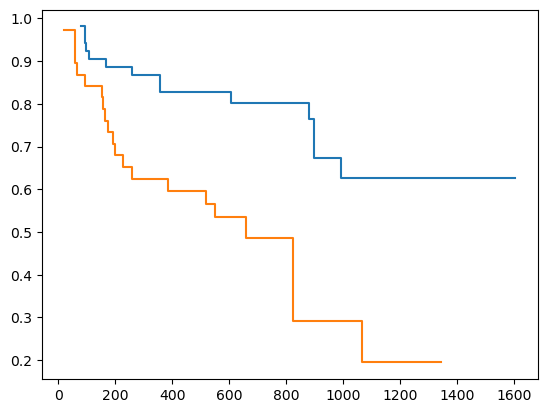

In [46]:
for prediction in (True, False):
    mask_treat = df['prediction'] == prediction
    time_treatment, survival_prob_treatment = kaplan_meier_estimator(
        df['event'][mask_treat],
        df['OS'][mask_treat])

    plt.step(time_treatment, survival_prob_treatment, where="post",
             label="Predict response = %s" % prediction)

In [122]:
time_treatment, survival_prob_treatment = kaplan_meier_estimator(
        df['event'][mask_treat],
        df['OS'][mask_treat])
print(df['OS'][mask_treat])
print(time_treatment)
len(set(df['OS'][mask_treat]))
print(survival_prob_treatment)

5      300.0
7      176.0
8       59.0
11    1342.0
13     166.0
18     155.0
20     609.0
22    1067.0
24    1328.0
26     551.0
27     156.0
30      58.0
32      65.0
33     689.0
35     689.0
36     637.0
46     825.0
47     627.0
49     660.0
50      96.0
52     191.0
53     551.0
54     530.0
61     506.0
64     825.0
67     199.0
68     635.0
69     518.0
71      58.0
72     551.0
76     228.0
77     129.0
78     691.0
80     721.0
81     258.0
83     385.0
85     695.0
86      22.0
Name: OS, dtype: float64
[  22.   58.   59.   65.   96.  129.  155.  156.  166.  176.  191.  199.
  228.  258.  300.  385.  506.  518.  530.  551.  609.  627.  635.  637.
  660.  689.  691.  695.  721.  825. 1067. 1328. 1342.]
[0.97368421 0.92105263 0.89473684 0.86842105 0.84210526 0.84210526
 0.81494058 0.78777589 0.76061121 0.73344652 0.70628183 0.67911715
 0.65195246 0.62478778 0.62478778 0.59638833 0.59638833 0.56656891
 0.56656891 0.53509286 0.53509286 0.53509286 0.53509286 0.53509286
 0.48644806

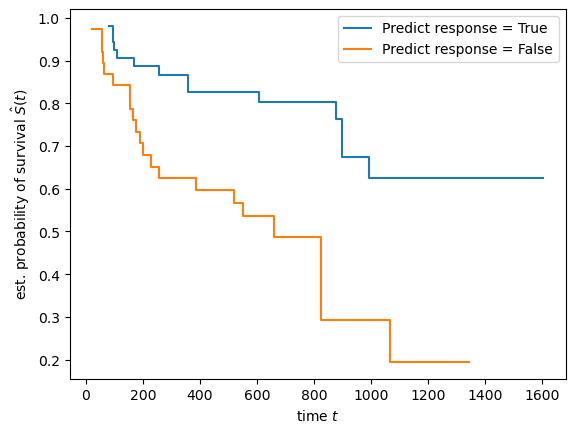

In [47]:
for prediction in (True, False):
    mask_treat = df['prediction'] == prediction
    time_treatment, survival_prob_treatment = kaplan_meier_estimator(
        df['event'][mask_treat],
        df['OS'][mask_treat])

    plt.step(time_treatment, survival_prob_treatment, where="post",
             label="Predict response = %s" % prediction)

plt.ylabel("est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")
plt.legend(loc="best")
plt.savefig('combine_sur.png')
plt.show()

0.6399082568807339


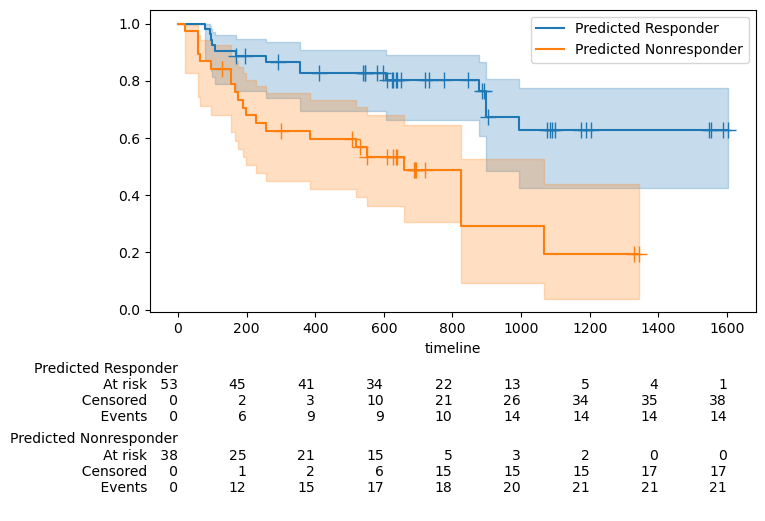

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          12.11 <0.005     10.96

              coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                 
group     -1.17358   0.309258  0.354479       -1.868347       -0.478814   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
group                 0.154379             0.619518     0.0 -3.310718   

                  p   -log2(p)  
covariate                       
group      0.000931  10.069599  


In [63]:
#Harrell’s concordance index 
from sksurv.metrics import concordance_index_censored

# prediction = estimator.predict(data_x_numeric)
result = concordance_index_censored(df["event"], df["OS"], 1-df['pred_value'])
print(result[0])

# log-rank test
from lifelines import KaplanMeierFitter
group1=df[df['prediction']==True]
group2=df[df['prediction']==False]
T=group1['OS']
E=group1['event']
T1=group2['OS']
E1=group2['event']

kmf = KaplanMeierFitter()

# ax = plt.subplot(111)
# ax = kmf.fit(T, E, label="predicted responder").plot(ax=ax)
# # plt.subplots_adjust(bottom=0.7)
# ax = kmf.fit(T1, E1, label="predicted nonresponder").plot(ax=ax)
# # plt.savefig("whole_sur.png",dpi=1000)
# # plt.show()


fig, ax = plt.subplots(figsize=(8, 6)) 
kmf.fit(T, E, label="Predicted Responder")
ax = kmf.plot(ax=ax, show_censors=True, ci_show=True, at_risk_counts=True)  # Display number at risk counts
kmf.fit(T1, E1, label="Predicted Nonresponder")
plt.subplots_adjust(bottom=0.7) 
ax = kmf.plot(ax=ax, show_censors=True, ci_show=True, at_risk_counts=True)  # Display number at risk counts
# plt.title("Survival Curves with Number at Risk")
# plt.xlabel("Time")
# plt.ylabel("Survival Probability")
plt.tight_layout(pad=2)
plt.savefig("whole_sur.png", dpi=1000)  # Save the figure with a high resolution
plt.show()


#logrank_test
from lifelines.statistics import logrank_test
results=logrank_test(T,T1,event_observed_A=E, event_observed_B=E1)
results.print_summary()

from lifelines import CoxPHFitter
df['group'] = df['prediction'].apply(lambda x: 1 if x else 0)
cph = CoxPHFitter()
cph.fit(df, duration_col='OS', event_col='event', formula="group")
print(cph.summary)

41
50


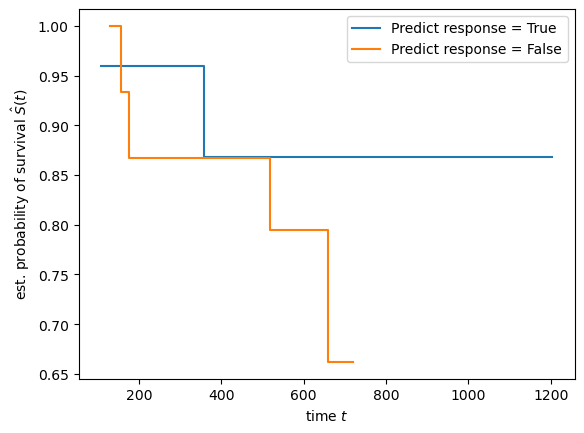

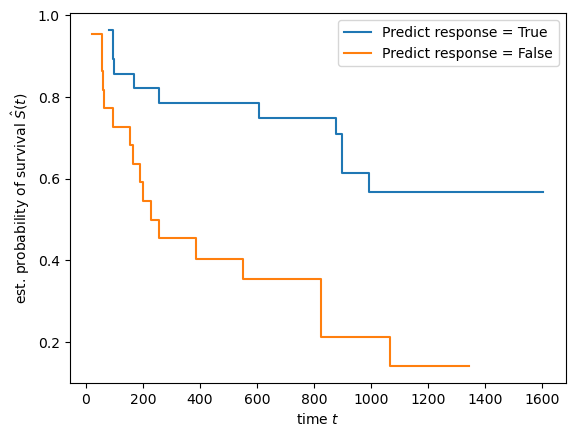

In [35]:

result_ipipd1=[]
result_pd1=[]
for i in range(5):
    info=result_info[i]
    pred=np.array(result_pred[i])[:,1]
    for j in range(info.shape[0]):
        # print(pred[j])
        pt=info[j].split('_')[3]
        num=pt2num[pt]
        p=pred[j]>=0.5
        OS=float(ptnum2OS[num])
        event=ptnum2Event[num]=='1'
        tem=[]
        tem.append(pt)
        tem.append(p)
        tem.append(pred[j])
        tem.append(OS)
        tem.append(event)
        if 'ipi' in num:
            result_ipipd1.append(tem)
        else:
            result_pd1.append(tem)
        
import pandas as pd
df_ipipd1 = pd.DataFrame(result_ipipd1, columns=['pt','prediction','pred_value','OS','event'])
df_pd1 = pd.DataFrame(result_pd1, columns=['pt','prediction','pred_value','OS','event'])

print(len(df_ipipd1))
print(len(df_pd1))

import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator

for prediction in (True, False):
    mask_treat = df_ipipd1['prediction'] == prediction
    time_treatment, survival_prob_treatment = kaplan_meier_estimator(
        df_ipipd1['event'][mask_treat],
        df_ipipd1['OS'][mask_treat])

    plt.step(time_treatment, survival_prob_treatment, where="post",
             label="Predict response = %s" % prediction)

plt.ylabel("est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")
plt.legend(loc="best")
plt.savefig('ipipd1_sur.png')
plt.show()

for prediction in (True, False):
    mask_treat = df_pd1['prediction'] == prediction
    time_treatment, survival_prob_treatment = kaplan_meier_estimator(
        df_pd1['event'][mask_treat],
        df_pd1['OS'][mask_treat])

    plt.step(time_treatment, survival_prob_treatment, where="post",
             label="Predict response = %s" % prediction)

plt.ylabel("est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")
plt.legend(loc="best")
plt.savefig('pd1_sur.png')

ipipd1   0.5576036866359447


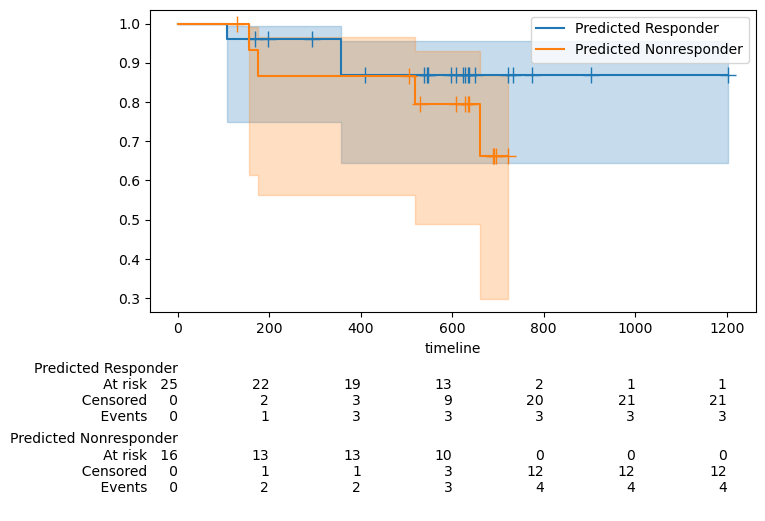

In [65]:
#Harrell’s concordance index 
from sksurv.metrics import concordance_index_censored

# prediction = estimator.predict(data_x_numeric)
result = concordance_index_censored(df_ipipd1["event"], df_ipipd1["OS"], 1-df_ipipd1['pred_value'])
print("ipipd1   "+str(result[0]))


# log-rank test
from lifelines import KaplanMeierFitter
group1=df_ipipd1[df_ipipd1['prediction']==True]
group2=df_ipipd1[df_ipipd1['prediction']==False]
T=group1['OS']
E=group1['event']
T1=group2['OS']
E1=group2['event']

kmf = KaplanMeierFitter()

# ax = plt.subplot(111)
# ax = kmf.fit(T, E, label="predicted responder").plot(ax=ax)
# ax = kmf.fit(T1, E1, label="predicted nonresponder").plot(ax=ax)
# plt.savefig("ipipd1_sur.png",dpi=1000)

fig, ax = plt.subplots(figsize=(8, 6)) 
kmf.fit(T, E, label="Predicted Responder")
ax = kmf.plot(ax=ax, show_censors=True, ci_show=True, at_risk_counts=True)  # Display number at risk counts
kmf.fit(T1, E1, label="Predicted Nonresponder")
plt.subplots_adjust(bottom=0.7) 
ax = kmf.plot(ax=ax, show_censors=True, ci_show=True, at_risk_counts=True)  # Display number at risk counts
# plt.title("Survival Curves with Number at Risk")
# plt.xlabel("Time")
# plt.ylabel("Survival Probability")
plt.tight_layout(pad=2)
plt.savefig("ipipd1_sur.png", dpi=1000)  # Save the figure with a high resolution
plt.show()


pd1   0.673773987206823


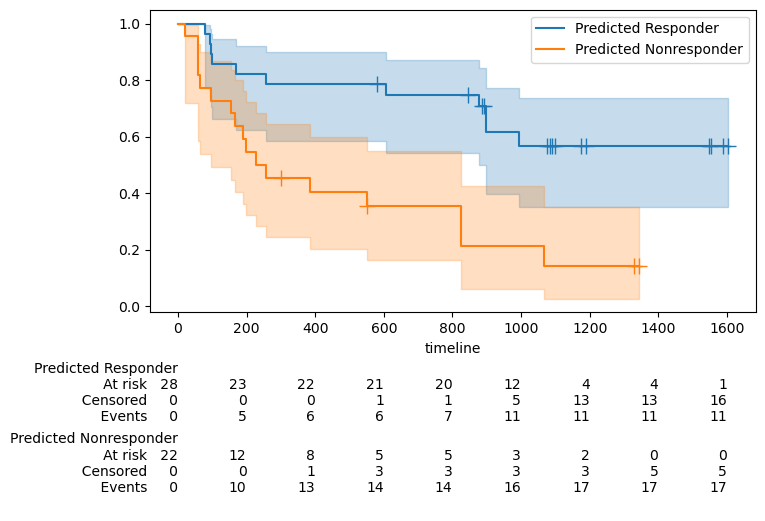

In [67]:
#Harrell’s concordance index 
from sksurv.metrics import concordance_index_censored

# prediction = estimator.predict(data_x_numeric)

result = concordance_index_censored(df_pd1["event"], df_pd1["OS"], 1-df_pd1['pred_value'])
print("pd1   "+str(result[0]))


group1=df_pd1[df_pd1['prediction']==True]
group2=df_pd1[df_pd1['prediction']==False]
T=group1['OS']
E=group1['event']
T1=group2['OS']
E1=group2['event']

kmf = KaplanMeierFitter()

# ax = plt.subplot(111)
# ax = kmf.fit(T, E, label="predicted responder").plot(ax=ax)
# ax = kmf.fit(T1, E1, label="predicted nonresponder").plot(ax=ax)
# plt.savefig("pd1_sur.png",dpi=1000)

fig, ax = plt.subplots(figsize=(8, 6)) 
kmf.fit(T, E, label="Predicted Responder")
ax = kmf.plot(ax=ax, show_censors=True, ci_show=True, at_risk_counts=True)  # Display number at risk counts
kmf.fit(T1, E1, label="Predicted Nonresponder")
plt.subplots_adjust(bottom=0.7) 
ax = kmf.plot(ax=ax, show_censors=True, ci_show=True, at_risk_counts=True)  # Display number at risk counts
# plt.title("Survival Curves with Number at Risk")
# plt.xlabel("Time")
# plt.ylabel("Survival Probability")
plt.tight_layout(pad=2)
plt.savefig("pd1_sur.png", dpi=1000)  # Save the figure with a high resolution
plt.show()


ipipd1   0.5576036866359447
pd1   0.673773987206823


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.78 0.38      1.41

               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
group     -0.656655   0.518583  0.768056       -2.162017        0.848706   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
group                 0.115093             2.336621     0.0 -0.854958   

                  p  -log2(p)  
covariate                      
group      0.392574  1.348962  


C:\Users\yjm85\Anaconda3\envs\Immunotherapy4\lib\site-packages\ipykernel_launcher.py:47: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          11.31 <0.005     10.34

               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
group     -1.268174   0.281345  0.398525        -2.04927       -0.487079   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
group                 0.128829             0.614419     0.0 -3.182167   

                  p  -log2(p)  
covariate                      
group      0.001462  9.418061  


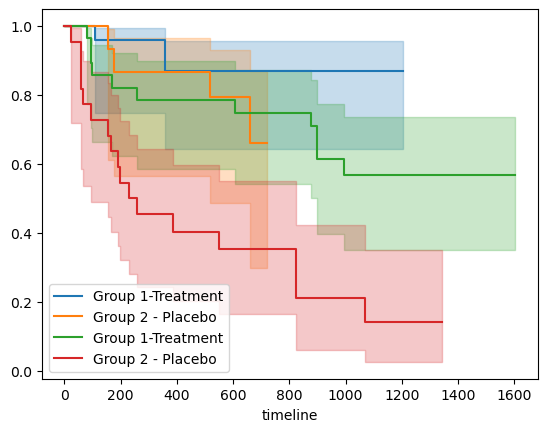

In [37]:
#Harrell’s concordance index 
from sksurv.metrics import concordance_index_censored

# prediction = estimator.predict(data_x_numeric)
result = concordance_index_censored(df_ipipd1["event"], df_ipipd1["OS"], 1-df_ipipd1['pred_value'])
print("ipipd1   "+str(result[0]))

result = concordance_index_censored(df_pd1["event"], df_pd1["OS"], 1-df_pd1['pred_value'])
print("pd1   "+str(result[0]))

# log-rank test
from lifelines import KaplanMeierFitter
group1=df_ipipd1[df_ipipd1['prediction']==True]
group2=df_ipipd1[df_ipipd1['prediction']==False]
T=group1['OS']
E=group1['event']
T1=group2['OS']
E1=group2['event']

kmf = KaplanMeierFitter()

ax = plt.subplot(111)
ax = kmf.fit(T, E, label="Group 1-Treatment").plot(ax=ax)
ax = kmf.fit(T1, E1, label="Group 2 - Placebo").plot(ax=ax)

#logrank_test
from lifelines.statistics import logrank_test
results=logrank_test(T,T1,event_observed_A=E, event_observed_B=E1)
results.print_summary()

from lifelines import CoxPHFitter
df_ipipd1['group'] = df_ipipd1['prediction'].apply(lambda x: 1 if x else 0)
cph = CoxPHFitter()
cph.fit(df_ipipd1, duration_col='OS', event_col='event', formula="group")
print(cph.summary)


group1=df_pd1[df_pd1['prediction']==True]
group2=df_pd1[df_pd1['prediction']==False]
T=group1['OS']
E=group1['event']
T1=group2['OS']
E1=group2['event']

kmf = KaplanMeierFitter()

ax = plt.subplot(111)
ax = kmf.fit(T, E, label="Group 1-Treatment").plot(ax=ax)
ax = kmf.fit(T1, E1, label="Group 2 - Placebo").plot(ax=ax)

#logrank_test
from lifelines.statistics import logrank_test
results=logrank_test(T,T1,event_observed_A=E, event_observed_B=E1)
results.print_summary()

from lifelines import CoxPHFitter
df_pd1['group'] = df_pd1['prediction'].apply(lambda x: 1 if x else 0)
cph = CoxPHFitter()
cph.fit(df_pd1, duration_col='OS', event_col='event', formula="group")
print(cph.summary)

In [32]:
# survival
# Riaz
random.seed(996)
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Riaz_zscore.npz')


random.seed(996)
cutoff=0.5
# [result_info, result_pred] = get_scores(datafromnpz,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1',cutoff,'random')
[result_info, result_pred] = get_scores(datafromnpz,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff,'random')


ptnum2OS={}
ptnum2Event={}
pt2num={}
fclinic=open("./tide_data/Riaz2017_PD1_Melanoma_RNASeq_Ipi.Naive/clinical.txt")
fpd1=open("./tide_data/Riaz2017_PD1_Melanoma_RNASeq_Ipi.Naive/Riaz2017_PD1_Melanoma_RNASeq_Ipi.Naive/ICB.Riaz2017_Nivolumab_Melanoma_Naive.clinical")

line=fpd1.readline()
lines=fpd1.readlines()
for i in lines:
    ptnum="PD1_"+i.split('\t')[0]
    OS=i.split('\t')[1]
    Event=i.split('\t')[2]
    ptnum2OS[ptnum]=OS
    ptnum2Event[ptnum]=Event
line=fclinic.readline()
lines=fclinic.readlines()
for i in lines:
    pt=i.split('\t')[0]
    num="PD1_"+i.split('\t')[0].split('_')[0]
    pt2num[pt]=num

fold 0 : 
[ 0  1  2  3  4  5  6  7  9 10]
['Riaz_Melanoma_RNAseq_Pt5_Pre_E9021022-6'
 'Riaz_Melanoma_RNAseq_Pt59_Pre_AD823915-5'
 'Riaz_Melanoma_RNAseq_Pt3_Pre_E9024733-3'
 'Riaz_Melanoma_RNAseq_Pt17_Pre_E9047563-6'
 'Riaz_Melanoma_RNAseq_Pt90_Pre_AD467873-6'
 'Riaz_Melanoma_RNAseq_Pt44_Pre_AD467790-6'
 'Riaz_Melanoma_RNAseq_Pt66_Pre_AD667850-6'
 'Riaz_Melanoma_RNAseq_Pt10_Pre_E9047565-6'
 'Riaz_Melanoma_RNAseq_Pt4_Pre_E9021023-6'
 'Riaz_Melanoma_RNAseq_Pt92_Pre_AE134060-5']
[0. 0. 1. 0. 0. 1. 0. 0. 0. 0.]
hyper-parameters:
0.0025
0.0025
0.0025
0.0025
0.5
0.4
0.4
4.0
4.0
4.0
8.0
8.0
fold 1 : 
[ 8 11 12 13 14 15 16 17 18 20]
['Riaz_Melanoma_RNAseq_Pt94_Pre_AD732850-6'
 'Riaz_Melanoma_RNAseq_Pt38_Pre_E9200719-6'
 'Riaz_Melanoma_RNAseq_Pt26_Pre_AD467789-6'
 'Riaz_Melanoma_RNAseq_Pt89_Pre_AE070951-5'
 'Riaz_Melanoma_RNAseq_Pt67_Pre_AD506074-6'
 'Riaz_Melanoma_RNAseq_Pt72_Pre_AD793922-5'
 'Riaz_Melanoma_RNAseq_Pt27_Pre_AD453873-5'
 'Riaz_Melanoma_RNAseq_Pt84_Pre_AD486532-5'
 'Riaz_Melanoma_

In [227]:
ptnum2OS
# ptnum2Event
# pt2num

{'PD1_Pt10': '256',
 'PD1_Pt11': '837',
 'PD1_Pt18': '1073',
 'PD1_Pt23': '52',
 'PD1_Pt24': '149',
 'PD1_Pt27': '475',
 'PD1_Pt28': '740',
 'PD1_Pt29': '273',
 'PD1_Pt3': '1144',
 'PD1_Pt30': '1053',
 'PD1_Pt31': '961',
 'PD1_Pt4': '633',
 'PD1_Pt44': '1093',
 'PD1_Pt5': '222',
 'PD1_Pt59': '708',
 'PD1_Pt62': '472',
 'PD1_Pt66': '542',
 'PD1_Pt72': '770',
 'PD1_Pt76': '10',
 'PD1_Pt77': '471',
 'PD1_Pt8': '259',
 'PD1_Pt84': '151',
 'PD1_Pt89': '844',
 'PD1_Pt9': '92',
 'PD1_Pt94': '981'}

In [33]:
result=[]
for i in range(5):
    info=result_info[i]
    pred=np.array(result_pred[i])[:,1]
    for j in range(info.shape[0]):
        # print(pred[j])
        pt=info[j][21:]
        num=pt2num[pt]
        p=pred[j]>=0.5
        if not num in ptnum2OS.keys():
            continue
        OS=float(ptnum2OS[num])
        event=ptnum2Event[num]=='1'
        tem=[]
        tem.append(pt)
        tem.append(p)
        tem.append(OS)
        tem.append(event)
        result.append(tem)
        
import pandas as pd
df = pd.DataFrame(result, columns=['pt','prediction','OS','event'])
df

,pt,prediction,OS,event
0,Pt5_Pre_E9021022-6,True,222.0,True
1,Pt59_Pre_AD823915-5,True,708.0,True
2,Pt3_Pre_E9024733-3,True,1144.0,False
3,Pt44_Pre_AD467790-6,True,1093.0,False
4,Pt66_Pre_AD667850-6,False,542.0,True
5,Pt10_Pre_E9047565-6,True,256.0,True
6,Pt4_Pre_E9021023-6,True,633.0,True
7,Pt94_Pre_AD732850-6,True,981.0,False
8,Pt89_Pre_AE070951-5,True,844.0,True
9,Pt72_Pre_AD793922-5,True,770.0,True


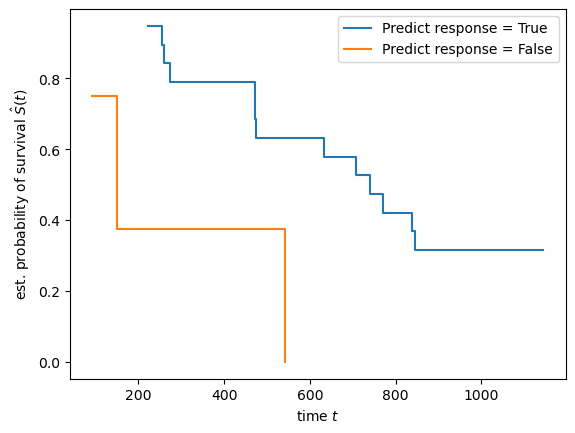

In [34]:
for prediction in (True, False):
    mask_treat = df['prediction'] == prediction
    time_treatment, survival_prob_treatment = kaplan_meier_estimator(
        df['event'][mask_treat],
        df['OS'][mask_treat])

    plt.step(time_treatment, survival_prob_treatment, where="post",
             label="Predict response = %s" % prediction)

plt.ylabel("est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")
plt.legend(loc="best")
plt.savefig('combine_sur.png')
plt.show()

(45, 344, 4)
(4, 8)
(45, 344, 4)
(4, 8)
(45, 344)


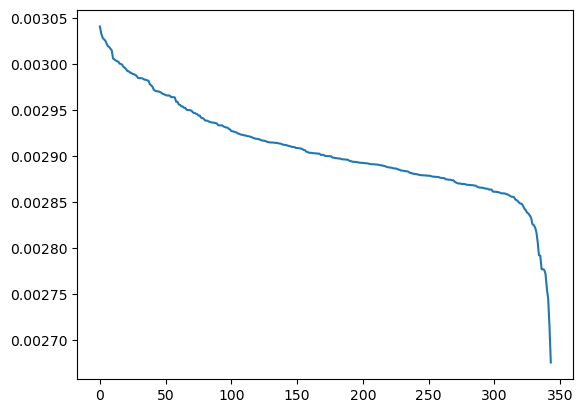

Index(['path:hsa00920', 'path:hsa00430', 'path:hsa00290', 'path:hsa00270',
       'path:hsa00770', 'path:hsa00280', 'path:hsa00970', 'path:hsa00640',
       'path:hsa00410', 'path:hsa03018', 'path:hsa00620', 'path:hsa00730',
       'path:hsa00260', 'path:hsa00340', 'path:hsa00440', 'path:hsa00760',
       'path:hsa00470', 'path:hsa00240', 'path:hsa00220', 'path:hsa00750',
       'path:hsa00910', 'path:hsa00330', 'path:hsa00480', 'path:hsa00650',
       'path:hsa00360'],
      dtype='object')


In [38]:
# PD1/Kim  
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Kim_zscore.npz')
# pathway_importance=get_pathway_importance(datafromnpz,model,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')[0]
# prediction=get_pathway_importance(datafromnpz,model,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')[1]
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
prediction=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[1]
print(pathway_importance.shape)
pathway_mean=np.mean(pathway_importance,axis=0)
pathway_order_H2L=pathway_mean.argsort()[::-1]

import matplotlib.pyplot as plt
plt.plot(pathway_mean[pathway_order_H2L])
plt.show()
print(pathways[pathway_order_H2L[:25]])

In [103]:
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Kim_zscore.npz')
pathway_importance=get_pathway_importance(datafromnpz,model,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')[0]

(45, 344, 4)
(4, 8)


(192, 344, 4)
(4, 8)
(192, 344, 4)
(4, 8)
(192, 344)
Index(['path:hsa00280', 'path:hsa00920', 'path:hsa00640', 'path:hsa00290',
       'path:hsa00770', 'path:hsa00430', 'path:hsa00410', 'path:hsa00270',
       'path:hsa00240', 'path:hsa00750', 'path:hsa00232', 'path:hsa00620',
       'path:hsa00440', 'path:hsa00910', 'path:hsa00052', 'path:hsa00730',
       'path:hsa00053', 'path:hsa00470', 'path:hsa00340', 'path:hsa00220',
       'path:hsa00310', 'path:hsa00970', 'path:hsa00480', 'path:hsa00260',
       'path:hsa00630', 'path:hsa00051', 'path:hsa00524', 'path:hsa00030',
       'path:hsa00760', 'path:hsa04216'],
      dtype='object')


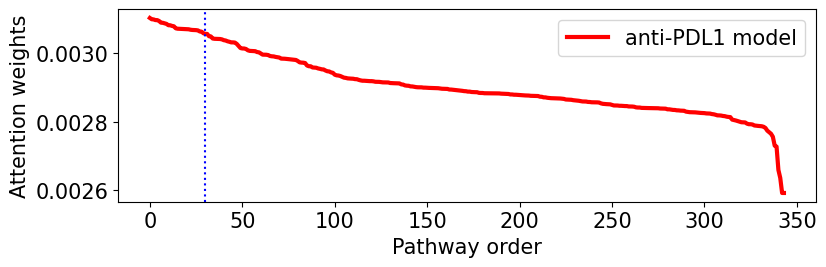

In [177]:
# PDl1/IMvigor # by prediction
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_IMvigor_zscore.npz')
# pathway_importance=get_pathway_importance(datafromnpz,model,'../tem/','IMvigor_bsp_TCGAtrans_randParam_','va_f1')[0]
# prediction=get_pathway_importance(datafromnpz,model,'../tem/','IMvigor_bsp_TCGAtrans_randParam_','va_f1')[1]
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
prediction=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[1]
print(pathway_importance.shape)
pathway_mean=np.mean(pathway_importance,axis=0)
pathway_order_H2L=pathway_mean.argsort()[::-1]

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 15})
plt.figure(figsize=(9, 2.5), dpi=100)
plt.plot(pathway_mean[pathway_order_H2L],color="red",label="anti-PDL1 model",linewidth=3)
plt.axvline(x = 30, color = 'b',ls=":")
plt.ylabel("Attention weights")
plt.xlabel("Pathway order")
plt.legend(loc="best")
# plt.show()
plt.savefig('PDL1_pathweight.png',dpi=100)
print(pathways[pathway_order_H2L[:30]])


f=open("./pathway_mapping.txt")
pathway2name={}
lines=f.readlines()
for l in lines:
    sep=l.strip().split('  ')
    if len(sep)==2:
        pid=sep[0]
        pname=sep[1]
        pathway2name[pid]=pname

f=open("./pdl1_entirelist.txt",'w')
for i in pathway_order_H2L:
    id=pathways[i][-5:]
    if id in pathway2name.keys():
        f.write(pathways[i]+"\t"+pathway2name[id]+"\t"+str(pathway_mean[i])+"\n")
f.close()

In [31]:
# get important genes in the top pathways
#PDL1
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_IMvigor_zscore.npz')
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
prediction=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[1]
print(pathway_importance.shape)
pathway_mean=np.mean(pathway_importance,axis=0)
pathway_order_H2L=pathway_mean.argsort()[::-1]
print(pathways[pathway_order_H2L[:30]])

from scipy.special import softmax
from scipy import stats
def get_import_genelist(model,gene_id_list,pid, mapp, genes, weight_folder,weight_presuffix,weight_metric):
    weights=np.zeros([5,33170])
    for fold in range(5):
        model.load_weights(weight_folder+weight_presuffix+str(fold)+'/_'+weight_metric)
        weights[fold,:]=np.array(model.weights[0])
    weights=np.mean(weights,axis=0)
    # model.load_weights("../tem/SKCM_bsp_randParam_"+str(fold)+"/_va_f1")
    # weights=model.weights[0]
    nonzero_ind=np.array(np.nonzero(mapp)).T
    weight_matrix=np.zeros([mapp.shape[0],mapp.shape[1]])
    for i in range(nonzero_ind.shape[0]):
        x=nonzero_ind[i,0]
        y=nonzero_ind[i,1]
        weight_matrix[x,y] = weights[i]
    persentile=[]
    for i in gene_id_list:
            ind=i
            j=weight_matrix[ind,pid]
            if j==0:
                continue
            p=stats.percentileofscore(weights, j, kind='rank')
            if p<=50:
                p=100-p
            if p>95:
                persentile.append(genes[i])
    return ",".join(persentile)


for pid in pathway_order_H2L[:30]:
    pathway_name=pathways[pid]
    gene_ids=[i for i,x in enumerate(mapp[:,pid]) if x>0 ]
    gene_list=get_import_genelist(model,gene_ids,pid,mapp,genes,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    print(pathway_name+"\t"+gene_list)

        



(192, 344, 4)
(4, 8)
(192, 344, 4)
(4, 8)
(192, 344)
Index(['path:hsa00280', 'path:hsa00920', 'path:hsa00640', 'path:hsa00290',
       'path:hsa00770', 'path:hsa00430', 'path:hsa00410', 'path:hsa00270',
       'path:hsa00240', 'path:hsa00750', 'path:hsa00232', 'path:hsa00620',
       'path:hsa00440', 'path:hsa00910', 'path:hsa00052', 'path:hsa00730',
       'path:hsa00053', 'path:hsa00470', 'path:hsa00340', 'path:hsa00220',
       'path:hsa00310', 'path:hsa00970', 'path:hsa00480', 'path:hsa00260',
       'path:hsa00630', 'path:hsa00051', 'path:hsa00524', 'path:hsa00030',
       'path:hsa00760', 'path:hsa04216'],
      dtype='object')
path:hsa00280	HMGCS2,MCCC2
path:hsa00920	
path:hsa00640	LDHA,ACOX1
path:hsa00290	
path:hsa00770	
path:hsa00430	
path:hsa00410	
path:hsa00270	LDHA,MDH1,GOT2,PHGDH,BHMT,DNMT1,DNMT3B,MAT2A,MTAP,TST
path:hsa00240	CTPS1
path:hsa00750	
path:hsa00232	
path:hsa00620	LDHA,PKM,MDH1
path:hsa00440	
path:hsa00910	
path:hsa00052	AKR1B1
path:hsa00730	
path:hsa00053	
path

In [28]:
",".join(["a","b"])

'a,b'

In [27]:
len()

48

In [18]:
pathway_order_H2L

array([ 22,  79,  64,  23,  71,  32,  31,  21,  18,  69,  17,  62,  33,
        78,   5,  67,   6,  35,  26,  15,  24,  80,  36,  20,  63,   4,
        45,   2,  70, 152,  28,  65,  19,  72,  51,  25,  68,  94,   3,
        30,  76,  44,  74, 137,   0, 248,  16, 104,   8, 273, 103, 135,
         1,  42,  57,  38,  75,  73, 326,  29,  40,  77,  81,  52,  41,
        58,   9,  43, 144,  59,  54,   7, 213,  12,  48,  61,  37,  53,
       112,  60,  27, 237,  83,  47, 228,  46,  39,  50, 211, 340,  97,
        49, 113, 307, 258, 200, 254, 100,  10, 224,  11, 225, 327,  66,
       318, 243, 153, 320,  14,  56, 249, 231, 250, 259, 274, 156, 323,
       309, 238, 253, 111, 227, 314, 128, 251, 230, 321, 315, 308, 119,
       305, 229, 240, 262, 310, 108, 322, 325,  89, 207, 260,  87, 299,
       261, 125, 107, 304, 126, 292, 263,  88, 212, 110, 252, 266, 172,
       319, 163, 216, 233, 294, 239, 217, 313, 301, 302, 232, 264,  34,
       206, 265, 311, 210, 283, 154, 343, 312, 256, 129, 117, 24

In [17]:
mapp.shape

(8080, 344)

In [16]:
pathways

Index(['path:hsa00010', 'path:hsa00020', 'path:hsa00030', 'path:hsa00040',
       'path:hsa00051', 'path:hsa00052', 'path:hsa00053', 'path:hsa00061',
       'path:hsa00062', 'path:hsa00071',
       ...
       'path:hsa05330', 'path:hsa05332', 'path:hsa05340', 'path:hsa05410',
       'path:hsa05412', 'path:hsa05414', 'path:hsa05415', 'path:hsa05416',
       'path:hsa05417', 'path:hsa05418'],
      dtype='object', length=344)

10
(37, 344, 4)
(4, 8)
(37, 344, 4)
(4, 8)
(10, 344)
Index(['path:hsa03018', 'path:hsa00430', 'path:hsa00920', 'path:hsa00770',
       'path:hsa00360', 'path:hsa00640', 'path:hsa00280', 'path:hsa00270',
       'path:hsa00290', 'path:hsa00410', 'path:hsa00620', 'path:hsa00650',
       'path:hsa00760', 'path:hsa00750', 'path:hsa00470', 'path:hsa00440',
       'path:hsa00260', 'path:hsa00220', 'path:hsa04216', 'path:hsa00970',
       'path:hsa00480', 'path:hsa00051', 'path:hsa00240', 'path:hsa00350',
       'path:hsa00052', 'path:hsa00730', 'path:hsa00910', 'path:hsa00053',
       'path:hsa00514', 'path:hsa00330'],
      dtype='object')


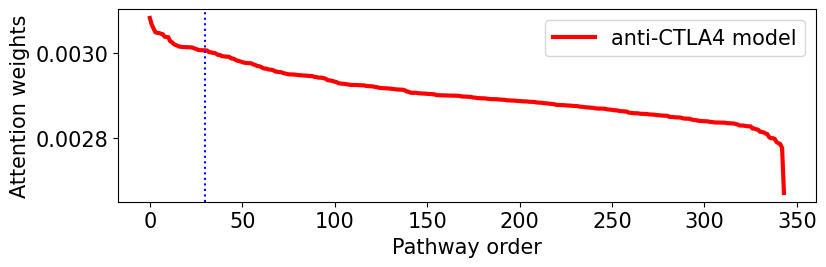

In [178]:
# CTLA4/Auslander
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
CTLA4=['115-031814','115-041514','208-10-22-14_S12','208-9-10-14_S11','MGH272-020415','MGH272-121914',
      'MGH422-092815','MGH422-110515','62-10-2-13_S6','62-5-27-14_S7']
ind=[]
for i in range(datafromnpz['info'].shape[0]):
    if datafromnpz['info'][i][26:-4] in CTLA4:
        ind.append(True)
    else:
        ind.append(False)
        
print(sum(ind))

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
# pathway_importance=get_pathway_importance(datafromnpz,model,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')[0]
# prediction=get_pathway_importance(datafromnpz,model,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')[1]
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
prediction=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[1]




pathway_importance=pathway_importance[ind]
prediction=prediction[ind]

print(pathway_importance.shape)
pathway_mean=np.mean(pathway_importance,axis=0)
pathway_order_H2L=pathway_mean.argsort()[::-1]

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 15})
plt.figure(figsize=(9, 2.5), dpi=100)
plt.plot(pathway_mean[pathway_order_H2L],color='red',label="anti-CTLA4 model",linewidth=3)
plt.axvline(x = 30, color = 'b',ls=":")
plt.ylabel("Attention weights")
plt.xlabel("Pathway order")
plt.legend(loc="best")
# plt.show()
plt.savefig('CTLA4_pathweight.png',dpi=100)
print(pathways[pathway_order_H2L[:30]])


f=open("./pathway_mapping.txt")
pathway2name={}
lines=f.readlines()
for l in lines:
    sep=l.strip().split('  ')
    if len(sep)==2:
        pid=sep[0]
        pname=sep[1]
        pathway2name[pid]=pname

f=open("./ctla4_entirelist.txt",'w')
for i in pathway_order_H2L:
    id=pathways[i][-5:]
    if id in pathway2name.keys():
        f.write(pathways[i]+"\t"+pathway2name[id]+"\t"+str(pathway_mean[i])+"\n")
f.close()

In [32]:
# get important genes in the top pathways
# CTLA4/Auslander
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
CTLA4=['115-031814','115-041514','208-10-22-14_S12','208-9-10-14_S11','MGH272-020415','MGH272-121914',
      'MGH422-092815','MGH422-110515','62-10-2-13_S6','62-5-27-14_S7']
ind=[]
for i in range(datafromnpz['info'].shape[0]):
    if datafromnpz['info'][i][26:-4] in CTLA4:
        ind.append(True)
    else:
        ind.append(False)
        
print(sum(ind))

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
# pathway_importance=get_pathway_importance(datafromnpz,model,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')[0]
# prediction=get_pathway_importance(datafromnpz,model,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')[1]
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
prediction=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[1]
pathway_importance=pathway_importance[ind]
prediction=prediction[ind]


print(pathway_importance.shape)
pathway_mean=np.mean(pathway_importance,axis=0)
pathway_order_H2L=pathway_mean.argsort()[::-1]
print(pathways[pathway_order_H2L[:30]])

from scipy.special import softmax
from scipy import stats
def get_import_genelist(model,gene_id_list,pid, mapp, genes, weight_folder,weight_presuffix,weight_metric):
    weights=np.zeros([5,33170])
    for fold in range(5):
        model.load_weights(weight_folder+weight_presuffix+str(fold)+'/_'+weight_metric)
        weights[fold,:]=np.array(model.weights[0])
    weights=np.mean(weights,axis=0)
    # model.load_weights("../tem/SKCM_bsp_randParam_"+str(fold)+"/_va_f1")
    # weights=model.weights[0]
    nonzero_ind=np.array(np.nonzero(mapp)).T
    weight_matrix=np.zeros([mapp.shape[0],mapp.shape[1]])
    for i in range(nonzero_ind.shape[0]):
        x=nonzero_ind[i,0]
        y=nonzero_ind[i,1]
        weight_matrix[x,y] = weights[i]
    persentile=[]
    for i in gene_id_list:
            ind=i
            j=weight_matrix[ind,pid]
            if j==0:
                continue
            p=stats.percentileofscore(weights, j, kind='rank')
            if p<=50:
                p=100-p
            if p>95:
                persentile.append(genes[i])
    return ",".join(persentile)


for pid in pathway_order_H2L[:30]:
    pathway_name=pathways[pid]
    gene_ids=[i for i,x in enumerate(mapp[:,pid]) if x>0 ]
    gene_list=get_import_genelist(model,gene_ids,pid,mapp,genes,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    print(pathway_name+"\t"+gene_list)

        



10
(37, 344, 4)
(4, 8)
(37, 344, 4)
(4, 8)
(10, 344)
Index(['path:hsa03018', 'path:hsa00430', 'path:hsa00920', 'path:hsa00770',
       'path:hsa00360', 'path:hsa00640', 'path:hsa00280', 'path:hsa00270',
       'path:hsa00290', 'path:hsa00410', 'path:hsa00620', 'path:hsa00650',
       'path:hsa00760', 'path:hsa00750', 'path:hsa00470', 'path:hsa00440',
       'path:hsa00260', 'path:hsa00220', 'path:hsa04216', 'path:hsa00970',
       'path:hsa00480', 'path:hsa00051', 'path:hsa00240', 'path:hsa00350',
       'path:hsa00052', 'path:hsa00730', 'path:hsa00910', 'path:hsa00053',
       'path:hsa00514', 'path:hsa00330'],
      dtype='object')
path:hsa03018	ENO1,PABPC1,CNOT1,HSPA9,HSPD1,CNOT2
path:hsa00430	
path:hsa00920	
path:hsa00770	
path:hsa00360	
path:hsa00640	LDHA,SUCLG2,ACACB,HADHA,PCCA
path:hsa00280	HADHB,OXCT1
path:hsa00270	LDHA,PHGDH,PSAT1,AHCYL1,AHCYL2,AMD1,GSS,MAT1A,MAT2A,MTAP,SMS,TST
path:hsa00290	
path:hsa00410	HADHA
path:hsa00620	ADH1B,ALDH3A2,LDHA,ALDH7A1,ACSS2,ACACA,ACACB,ACAT1,

(119, 344, 4)
(4, 8)
(119, 344, 4)
(4, 8)
(119, 344)
Index(['path:hsa03018', 'path:hsa04217', 'path:hsa00430', 'path:hsa00920',
       'path:hsa03015', 'path:hsa04216', 'path:hsa00983', 'path:hsa00770',
       'path:hsa00270', 'path:hsa00290', 'path:hsa00640', 'path:hsa00410',
       'path:hsa04978', 'path:hsa05171', 'path:hsa00280', 'path:hsa00860',
       'path:hsa04974', 'path:hsa00620', 'path:hsa00240', 'path:hsa00260',
       'path:hsa00470', 'path:hsa00970', 'path:hsa00730', 'path:hsa00760',
       'path:hsa00910', 'path:hsa00650', 'path:hsa00480', 'path:hsa00220',
       'path:hsa00340', 'path:hsa05132'],
      dtype='object')


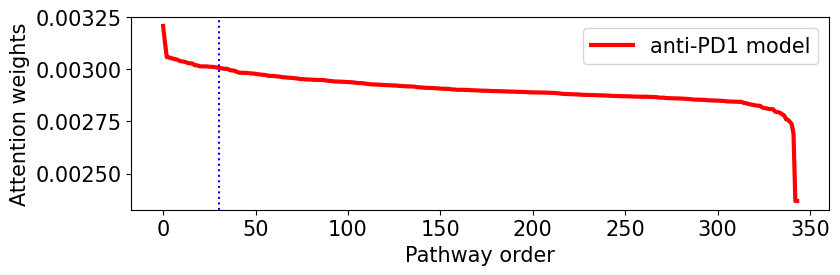

In [179]:
# Liu anti-PD1
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Liu_zscore.npz')
# pathway_importance=get_pathway_importance(datafromnpz,model,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1')[0]
# prediction=get_pathway_importance(datafromnpz,model,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1')[1]
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
prediction=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[1]



print(pathway_importance.shape)
pathway_mean=np.mean(pathway_importance,axis=0)
pathway_order_H2L=pathway_mean.argsort()[::-1]
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 15})
# plt.figure(facecolor=(1, 1, 1))
plt.figure(figsize=(9, 2.5), dpi=100)
plt.plot(pathway_mean[pathway_order_H2L],color='red',label='anti-PD1 model',linewidth=3)
plt.axvline(x = 30, color = 'b',ls=":")
plt.ylabel("Attention weights")
plt.xlabel("Pathway order")
plt.legend(loc="best")
# plt.show()
plt.savefig('PD1_pathweight.png',dpi=100)
print(pathways[pathway_order_H2L[:30]])


# responder_ind=prediction[:,1]>0.5
# nonres_ind=prediction[:,1]<=0.5
# responder_pathway=pathway_importance[responder_ind]
# nonres_pathway=pathway_importance[nonres_ind]
# responder_pathway_mean=np.mean(responder_pathway,axis=0)
# nonres_pathway_mean=np.mean(nonres_pathway,axis=0)
# responder_pathway_order_H2L=responder_pathway_mean.argsort()[::-1]
# nonres_pathway_order_H2L=nonres_pathway_mean.argsort()[::-1]
# import matplotlib.pyplot as plt
# plt.figure(figsize=(10,6))
# plt.plot(nonres_pathway_mean[nonres_pathway_order_H2L],label='non')
# plt.plot(responder_pathway_mean[responder_pathway_order_H2L],c='red',label='responder')
# plt.xticks(np.arange(0,344,10))
# plt.legend(loc="upper right")
# plt.show()
# print(pathways[nonres_pathway_order_H2L[:10]])
# print(pathways[responder_pathway_order_H2L[:10]])

f=open("./pathway_mapping.txt")
pathway2name={}
lines=f.readlines()
for l in lines:
    sep=l.strip().split('  ')
    if len(sep)==2:
        pid=sep[0]
        pname=sep[1]
        pathway2name[pid]=pname

f=open("./pd1_entirelist.txt",'w')
for i in pathway_order_H2L:
    id=pathways[i][-5:]
    if id in pathway2name.keys():
        f.write(pathways[i]+"\t"+pathway2name[id]+"\t"+str(pathway_mean[i])+"\n")
f.close()

In [33]:
# get important genes in the top pathways
# Liu anti-PD1
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Liu_zscore.npz')
# pathway_importance=get_pathway_importance(datafromnpz,model,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1')[0]
# prediction=get_pathway_importance(datafromnpz,model,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1')[1]
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
prediction=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[1]

print(pathway_importance.shape)
pathway_mean=np.mean(pathway_importance,axis=0)
pathway_order_H2L=pathway_mean.argsort()[::-1]
print(pathways[pathway_order_H2L[:30]])

from scipy.special import softmax
from scipy import stats
def get_import_genelist(model,gene_id_list,pid, mapp, genes, weight_folder,weight_presuffix,weight_metric):
    weights=np.zeros([5,33170])
    for fold in range(5):
        model.load_weights(weight_folder+weight_presuffix+str(fold)+'/_'+weight_metric)
        weights[fold,:]=np.array(model.weights[0])
    weights=np.mean(weights,axis=0)
    # model.load_weights("../tem/SKCM_bsp_randParam_"+str(fold)+"/_va_f1")
    # weights=model.weights[0]
    nonzero_ind=np.array(np.nonzero(mapp)).T
    weight_matrix=np.zeros([mapp.shape[0],mapp.shape[1]])
    for i in range(nonzero_ind.shape[0]):
        x=nonzero_ind[i,0]
        y=nonzero_ind[i,1]
        weight_matrix[x,y] = weights[i]
    persentile=[]
    for i in gene_id_list:
            ind=i
            j=weight_matrix[ind,pid]
            if j==0:
                continue
            p=stats.percentileofscore(weights, j, kind='rank')
            if p<=50:
                p=100-p
            if p>95:
                persentile.append(genes[i])
    return ",".join(persentile)


for pid in pathway_order_H2L[:30]:
    pathway_name=pathways[pid]
    gene_ids=[i for i,x in enumerate(mapp[:,pid]) if x>0 ]
    gene_list=get_import_genelist(model,gene_ids,pid,mapp,genes,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    print(pathway_name+"\t"+gene_list)

        



(119, 344, 4)
(4, 8)
(119, 344, 4)
(4, 8)
(119, 344)
Index(['path:hsa03018', 'path:hsa04217', 'path:hsa00430', 'path:hsa00920',
       'path:hsa03015', 'path:hsa04216', 'path:hsa00983', 'path:hsa00770',
       'path:hsa00270', 'path:hsa00290', 'path:hsa00640', 'path:hsa00410',
       'path:hsa04978', 'path:hsa05171', 'path:hsa00280', 'path:hsa00860',
       'path:hsa04974', 'path:hsa00620', 'path:hsa00240', 'path:hsa00260',
       'path:hsa00470', 'path:hsa00970', 'path:hsa00730', 'path:hsa00760',
       'path:hsa00910', 'path:hsa00650', 'path:hsa00480', 'path:hsa00220',
       'path:hsa00340', 'path:hsa05132'],
      dtype='object')
path:hsa03018	ENO1,PABPC1,DIS3L,CNOT1,HSPA9,HSPD1,CNOT2
path:hsa04217	PYGB,PPIA,FTH1,FTL
path:hsa00430	
path:hsa00920	
path:hsa03015	SRRM1,CASC3,ACIN1,TARDBP,FUS,PABPC1,PPP2R1A,PABPC1L,FIP1L1,PABPC4,SMG7
path:hsa04216	FTH1,FTL,SLC40A1,PCBP2
path:hsa00983	GUSB,UGT1A10,UGT2B7,UGT2B15,CYP3A4,IMPDH2,RRM2,DPYD,TYMP,TK1,UPP1,GSTM1,GSTM3,GSTM4,GSTP1,MGST1,MGST3,G

(119, 344, 4)
(4, 8)
(37, 344, 4)
(4, 8)
(192, 344, 4)
(4, 8)


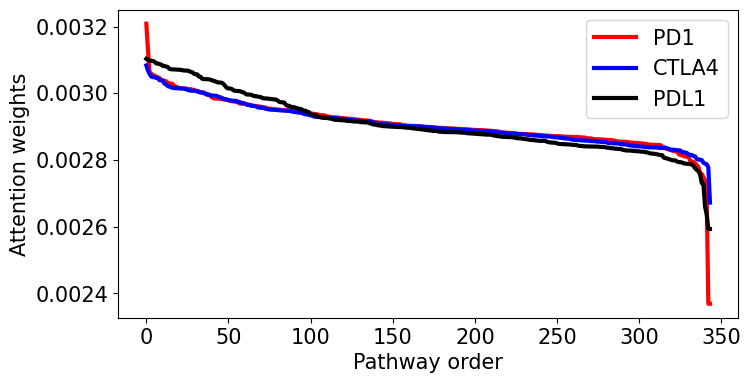

In [81]:
#tem for drawing
import matplotlib.pyplot as plt
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Liu_zscore.npz')
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
pathway_mean_pd1=np.mean(pathway_importance,axis=0)
pathway_order_H2L_pd1=pathway_mean_pd1.argsort()[::-1]

######

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
CTLA4=['115-031814','115-041514','208-10-22-14_S12','208-9-10-14_S11','MGH272-020415','MGH272-121914',
      'MGH422-092815','MGH422-110515','62-10-2-13_S6','62-5-27-14_S7']
ind=[]
for i in range(datafromnpz['info'].shape[0]):
    if datafromnpz['info'][i][26:-4] in CTLA4:
        ind.append(True)
    else:
        ind.append(False)

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
pathway_importance=pathway_importance[ind]
pathway_mean_ctla4=np.mean(pathway_importance,axis=0)
pathway_order_H2L_ctla4=pathway_mean_ctla4.argsort()[::-1]
#######
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_IMvigor_zscore.npz')
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
pathway_mean_pdl1=np.mean(pathway_importance,axis=0)
pathway_order_H2L_pdl1=pathway_mean_pdl1.argsort()[::-1]


plt.rcParams.update({'font.size': 15})
plt.figure(figsize=(8, 4), dpi=100)
plt.plot(pathway_mean_pd1[pathway_order_H2L_pd1],label="PD1",color='red',linewidth=3)
plt.plot(pathway_mean_ctla4[pathway_order_H2L_ctla4],label="CTLA4",color='blue',linewidth=3)
plt.plot(pathway_mean_pdl1[pathway_order_H2L_pdl1],label="PDL1",color='black',linewidth=3)



plt.ylabel("Attention weights")
plt.xlabel("Pathway order")
plt.legend(loc="best")
plt.show()
# plt.savefig('books_read.png')

30	30	30


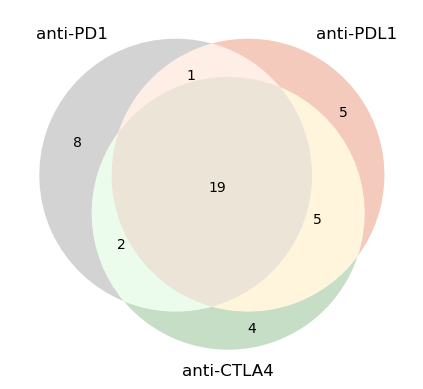

In [31]:
# compare 3 treatment
set_PD1_Kim=set([])
set_PD1_Liu=set(['path:hsa03018', 'path:hsa04217', 'path:hsa00430', 'path:hsa00920',
       'path:hsa03015', 'path:hsa04216', 'path:hsa00983', 'path:hsa00770',
       'path:hsa00270', 'path:hsa00290', 'path:hsa00640', 'path:hsa00410',
       'path:hsa04978', 'path:hsa05171', 'path:hsa00280', 'path:hsa00860',
       'path:hsa04974', 'path:hsa00620', 'path:hsa00240', 'path:hsa00260',
       'path:hsa00470', 'path:hsa00970', 'path:hsa00730', 'path:hsa00760',
       'path:hsa00910', 'path:hsa00650', 'path:hsa00480', 'path:hsa00220',
       'path:hsa00340', 'path:hsa05132'])
set_PDL1=set(['path:hsa00280', 'path:hsa00920', 'path:hsa00640', 'path:hsa00290',
       'path:hsa00770', 'path:hsa00430', 'path:hsa00410', 'path:hsa00270',
       'path:hsa00240', 'path:hsa00750', 'path:hsa00232', 'path:hsa00620',
       'path:hsa00440', 'path:hsa00910', 'path:hsa00052', 'path:hsa00730',
       'path:hsa00053', 'path:hsa00470', 'path:hsa00340', 'path:hsa00220',
       'path:hsa00310', 'path:hsa00970', 'path:hsa00480', 'path:hsa00260',
       'path:hsa00630', 'path:hsa00051', 'path:hsa00524', 'path:hsa00030',
       'path:hsa00760', 'path:hsa04216'])
set_CTLA4=set(['path:hsa03018', 'path:hsa00430', 'path:hsa00920', 'path:hsa00770',
       'path:hsa00360', 'path:hsa00640', 'path:hsa00280', 'path:hsa00270',
       'path:hsa00290', 'path:hsa00410', 'path:hsa00620', 'path:hsa00650',
       'path:hsa00760', 'path:hsa00750', 'path:hsa00470', 'path:hsa00440',
       'path:hsa00260', 'path:hsa00220', 'path:hsa04216', 'path:hsa00970',
       'path:hsa00480', 'path:hsa00051', 'path:hsa00240', 'path:hsa00350',
       'path:hsa00052', 'path:hsa00730', 'path:hsa00910', 'path:hsa00053',
       'path:hsa00514', 'path:hsa00330'])
print(str(len(set_PD1_Liu))+"\t"+str(len(set_PDL1))+"\t"+str(len(set_CTLA4)))

import matplotlib.pyplot as plt
from matplotlib_venn import venn3



venn3([set_PD1_Liu, set_PDL1, set_CTLA4], ('anti-PD1', 'anti-PDL1', 'anti-CTLA4'),set_colors=("darkgrey", "darksalmon", "darkseagreen"), alpha=0.5)
# venn3([set_PD1_Liu, set_PDL1, set_CTLA4], ('PD1', 'PDL1', 'CTLA4'),set_colors=("silver", "darkkhaki", "plum"), alpha=0.5)
# venn3([set_PD1_Liu, set_PDL1, set_CTLA4], ('PD1', 'PDL1', 'CTLA4'),set_colors=("rosybrown", "olivedrab", "slategray"), alpha=0.5)

# plt.show()
plt.savefig('venn.png',dpi=1000)

In [128]:
# pathway interaction
fn=open("KEGG_edgename.txt",'w')
f=open("./Kegg/human_KeggPathwayNet.txt")
l=f.readline()
while l!="":
    ln=l.strip()
    p1=ln.split("\t")[0]
    p2=ln.split('\t')[1]
    fn.write(ln+"\t"+p1+"_"+p2+"\n")
    l=f.readline()
fn.close()

In [33]:
# tem
#Liu, PD1, 5133 
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Liu_zscore.npz')
# pathway_relation=get_pathway_relation(datafromnpz,model,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1')
pathway_relation=get_pathway_relation(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
print(pathway_relation.shape)
pathway_relation_mean=np.mean(pathway_relation,axis=0)

# pathway_importance=get_pathway_importance(datafromnpz,model,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1')[0]
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
pathway_mean=np.mean(pathway_importance,axis=0)
pathway_order_H2L=pathway_mean.argsort()[::-1]
set_PD1_Liu=set(pathway_order_H2L[:30])

(119, 344, 344)
(119, 344, 4)
(4, 8)


In [36]:
# tem
ind=list(pathways).index('path:hsa04514')
# ind=list(pathways).index('path:hsa05235')
# ind=list(pathways).index('path:hsa04660')
pathway_list=pathway_relation_mean[ind]
n=sum(pathway_list!=0)
order=pathway_list.argsort()[::-1][:n]
pathways[order]

Index(['path:hsa05322', 'path:hsa05332', 'path:hsa05144', 'path:hsa05310',
       'path:hsa05330', 'path:hsa05160', 'path:hsa04658', 'path:hsa05320',
       'path:hsa04659', 'path:hsa05235', 'path:hsa04514', 'path:hsa04660',
       'path:hsa05418', 'path:hsa04610', 'path:hsa04670', 'path:hsa04520',
       'path:hsa04530'],
      dtype='object')

In [37]:
# tem, pdl1, 29126
# PDl1/IMvigor # by prediction
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_IMvigor_zscore.npz')
# pathway_relation=get_pathway_relation(datafromnpz,model,'../tem/','IMvigor_bsp_TCGAtrans_randParam_','va_f1')
pathway_relation=get_pathway_relation(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
print(pathway_relation.shape)
pathway_relation_mean=np.mean(pathway_relation,axis=0)

# pathway_importance=get_pathway_importance(datafromnpz,model,'../tem/','IMvigor_bsp_TCGAtrans_randParam_','va_f1')[0]
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
print(pathway_importance.shape)
pathway_mean=np.mean(pathway_importance,axis=0)
pathway_order_H2L=pathway_mean.argsort()[::-1]

(192, 344, 344)
(192, 344, 4)
(4, 8)
(192, 344)


In [39]:
# tem
# ind=list(pathways).index('path:hsa04514')
ind=list(pathways).index('path:hsa05235')
pathway_list=pathway_relation_mean[ind]
n=sum(pathway_list!=0)
order=pathway_list.argsort()[::-1][:n]
pathways[order]

Index(['path:hsa05235', 'path:hsa04620', 'path:hsa04660', 'path:hsa04514',
       'path:hsa04010', 'path:hsa04151', 'path:hsa04020', 'path:hsa04066'],
      dtype='object')

In [40]:
# tem, ctla4, 1493
# pathway interaction
# CTLA4/Auslander
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
CTLA4=['115-031814','115-041514','208-10-22-14_S12','208-9-10-14_S11','MGH272-020415','MGH272-121914',
      'MGH422-092815','MGH422-110515','62-10-2-13_S6','62-5-27-14_S7']
ind=[]
for i in range(datafromnpz['info'].shape[0]):
    if datafromnpz['info'][i][26:-4] in CTLA4:
        ind.append(True)
    else:
        ind.append(False)
        
print(sum(ind))

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
# pathway_relation=get_pathway_relation(datafromnpz,model,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')
pathway_relation=get_pathway_relation(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
pathway_relation=pathway_relation[ind]
print(pathway_relation.shape)
pathway_relation_mean=np.mean(pathway_relation,axis=0)

10
(10, 344, 344)


In [42]:
# tem
ind=list(pathways).index('path:hsa05320')
# ind=list(pathways).index('path:hsa05323')
pathway_list=pathway_relation_mean[ind]
n=sum(pathway_list!=0)
order=pathway_list.argsort()[::-1][:n]
pathways[order]

Index(['path:hsa05320', 'path:hsa04660', 'path:hsa04612', 'path:hsa04662',
       'path:hsa04514', 'path:hsa04610', 'path:hsa04918', 'path:hsa04210'],
      dtype='object')

In [151]:
# pathway interaction
#Liu, PD1
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Liu_zscore.npz')
# pathway_relation=get_pathway_relation(datafromnpz,model,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1')
pathway_relation=get_pathway_relation(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
print(pathway_relation.shape)
pathway_relation_mean=np.mean(pathway_relation,axis=0)

# pathway_importance=get_pathway_importance(datafromnpz,model,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1')[0]
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
pathway_mean=np.mean(pathway_importance,axis=0)
pathway_order_H2L=pathway_mean.argsort()[::-1]
set_PD1_Liu=set(pathway_order_H2L[:30])
top5_n=[]
fg=open("PD1_topgenelist.txt",'w')
fl=open("PD1_topinter.txt",'w')
for i in set_PD1_Liu:
    fg.write(str(pathways[i])+"\t1\n")
    pathway_list=pathway_relation_mean[i]
    n=sum(pathway_list!=0)
    order=pathway_list.argsort()[::-1][:n]
    if n<=3:
        for j in order:
            top5_n.append(j)
            if j in set_PD1_Liu:
                fl.write(str(pathways[i])+"\t"+str(pathways[j])+"\t"+str(1)+"\t1\n")
            else:
                fl.write(str(pathways[i])+"\t"+str(pathways[j])+"\t"+str(pathways[i])+"_"+str(pathways[j])+"\t1\n")
            # fl.write(str(pathways[j])+"\t"+str(pathways[i])+"\t"+str(pathways[j])+"_"+str(pathways[i])+"\t1\n")
    if n>3:
        for j in order[:3]:
            top5_n.append(j)
            if j in set_PD1_Liu:
                fl.write(str(pathways[i])+"\t"+str(pathways[j])+"\t"+str(1)+"\t1\n")
            else:
                fl.write(str(pathways[i])+"\t"+str(pathways[j])+"\t"+str(pathways[i])+"_"+str(pathways[j])+"\t1\n")
            # fl.write(str(pathways[j])+"\t"+str(pathways[i])+"\t"+str(pathways[j])+"_"+str(pathways[i])+"\t1\n")

fg.close()
fl.close()
newset=set(top5_n)
overlap=0
for i in newset:
    if i in set_PD1_Liu:
        overlap+=1
print(overlap/len(newset))




(119, 344, 344)
(119, 344, 4)
(4, 8)
0.5116279069767442


In [159]:
# calculate random interaction overlap
import random
random.seed(996)
def cal_overlap():
    rd_n=[]
    rd_set30=random.sample(set(pathway_order_H2L),30)
    for i in rd_set30:
        pathway_list=pathway_relation_mean[i]
        n=sum(pathway_list!=0)
        order=pathway_list.argsort()[::-1][:n]
        rd_order=random.sample(set(order),len(order))
        if n<=3:
            for j in rd_order:
                rd_n.append(j)
        if n>3:
            for j in rd_order[:3]:
                rd_n.append(j)
    
    newset=set(rd_n)
    overlap=0
    for i in newset:
        if i in rd_set30:
            overlap+=1
    ratio=overlap/len(newset)
    return ratio

print(cal_overlap())
print(cal_overlap())

ratio_list=[]
for i in range(10000):
    ratio_list.append(cal_overlap())


sum(np.array(ratio_list)>=0.5813)/len(ratio_list)

0.208955223880597
0.24242424242424243


0.0

In [158]:
# pathway interaction
# CTLA4/Auslander
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
CTLA4=['115-031814','115-041514','208-10-22-14_S12','208-9-10-14_S11','MGH272-020415','MGH272-121914',
      'MGH422-092815','MGH422-110515','62-10-2-13_S6','62-5-27-14_S7']
ind=[]
for i in range(datafromnpz['info'].shape[0]):
    if datafromnpz['info'][i][26:-4] in CTLA4:
        ind.append(True)
    else:
        ind.append(False)
        
print(sum(ind))

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
# pathway_relation=get_pathway_relation(datafromnpz,model,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')
pathway_relation=get_pathway_relation(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
pathway_relation=pathway_relation[ind]
print(pathway_relation.shape)
pathway_relation_mean=np.mean(pathway_relation,axis=0)

# pathway_importance=get_pathway_importance(datafromnpz,model,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')[0]
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
pathway_importance=pathway_importance[ind]
print("pathway: "+str(pathway_importance.shape))
pathway_mean=np.mean(pathway_importance,axis=0)

pathway_order_H2L=pathway_mean.argsort()[::-1]
set_PD1_Liu=set(pathway_order_H2L[:30])
top5_n=[]
fg=open("CTLA4_topgenelist.txt",'w')
fl=open("CTLA4_topinter.txt",'w')
for i in set_PD1_Liu:
    fg.write(str(pathways[i])+"\t1\n")
    pathway_list=pathway_relation_mean[i]
    n=sum(pathway_list!=0)
    order=pathway_list.argsort()[::-1][:n]
    if n<=3:
        for j in order:
            top5_n.append(j)
            if j in set_PD1_Liu:
                fl.write(str(pathways[i])+"\t"+str(pathways[j])+"\t"+str(1)+"\t1\n")
            else:
                fl.write(str(pathways[i])+"\t"+str(pathways[j])+"\t"+str(pathways[i])+"_"+str(pathways[j])+"\t1\n")
            # fl.write(str(pathways[j])+"\t"+str(pathways[i])+"\t"+str(pathways[j])+"_"+str(pathways[i])+"\t1\n")
    if n>3:
        for j in order[:3]:
            top5_n.append(j)
            if j in set_PD1_Liu:
                fl.write(str(pathways[i])+"\t"+str(pathways[j])+"\t"+str(1)+"\t1\n")
            else:
                fl.write(str(pathways[i])+"\t"+str(pathways[j])+"\t"+str(pathways[i])+"_"+str(pathways[j])+"\t1\n")
            # fl.write(str(pathways[j])+"\t"+str(pathways[i])+"\t"+str(pathways[j])+"_"+str(pathways[i])+"\t1\n")

fg.close()
fl.close()
newset=set(top5_n)
overlap=0
for i in newset:
    if i in set_PD1_Liu:
        overlap+=1
print(overlap/len(newset))



10
(10, 344, 344)
(37, 344, 4)
(4, 8)
pathway: (10, 344)
0.5813953488372093


In [156]:
# pathway interaction
# PDl1/IMvigor # by prediction
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_IMvigor_zscore.npz')
# pathway_relation=get_pathway_relation(datafromnpz,model,'../tem/','IMvigor_bsp_TCGAtrans_randParam_','va_f1')
pathway_relation=get_pathway_relation(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
print(pathway_relation.shape)
pathway_relation_mean=np.mean(pathway_relation,axis=0)

# pathway_importance=get_pathway_importance(datafromnpz,model,'../tem/','IMvigor_bsp_TCGAtrans_randParam_','va_f1')[0]
pathway_importance=get_pathway_importance(datafromnpz,model,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[0]
print(pathway_importance.shape)
pathway_mean=np.mean(pathway_importance,axis=0)
pathway_order_H2L=pathway_mean.argsort()[::-1]

set_PD1_Liu=set(pathway_order_H2L[:30])
top5_n=[]
fg=open("PDL1_topgenelist.txt",'w')
fl=open("PDL1_topinter.txt",'w')
for i in set_PD1_Liu:
    fg.write(str(pathways[i])+"\t1\n")
    pathway_list=pathway_relation_mean[i]
    n=sum(pathway_list!=0)
    order=pathway_list.argsort()[::-1][:n]
    if n<=3:
        for j in order:
            top5_n.append(j)
            if j in set_PD1_Liu:
                fl.write(str(pathways[i])+"\t"+str(pathways[j])+"\t"+str(1)+"\t1\n")
            else:
                fl.write(str(pathways[i])+"\t"+str(pathways[j])+"\t"+str(pathways[i])+"_"+str(pathways[j])+"\t1\n")
            # fl.write(str(pathways[j])+"\t"+str(pathways[i])+"\t"+str(pathways[j])+"_"+str(pathways[i])+"\t1\n")
    if n>3:
        for j in order[:3]:
            top5_n.append(j)
            if j in set_PD1_Liu:
                fl.write(str(pathways[i])+"\t"+str(pathways[j])+"\t"+str(1)+"\t1\n")
            else:
                fl.write(str(pathways[i])+"\t"+str(pathways[j])+"\t"+str(pathways[i])+"_"+str(pathways[j])+"\t1\n")
            # fl.write(str(pathways[j])+"\t"+str(pathways[i])+"\t"+str(pathways[j])+"_"+str(pathways[i])+"\t1\n")

fg.close()
fl.close()
newset=set(top5_n)
overlap=0
for i in newset:
    if i in set_PD1_Liu:
        overlap+=1
print(overlap/len(newset))

(192, 344, 344)
(192, 344, 4)
(4, 8)
(192, 344)
0.7222222222222222


In [113]:
# gene importance

from scipy.special import softmax
from scipy import stats

def get_gene_persentile(model,gene_name_list, mapp, genes, weight_folder,weight_presuffix,weight_metric):
    weights=np.zeros([5,33170])
    for fold in range(5):
        model.load_weights(weight_folder+weight_presuffix+str(fold)+'/_'+weight_metric)
        weights[fold,:]=np.array(model.weights[0])
    weights=np.mean(weights,axis=0)
    # model.load_weights("../tem/SKCM_bsp_randParam_"+str(fold)+"/_va_f1")
    # weights=model.weights[0]
    nonzero_ind=np.array(np.nonzero(mapp)).T
    weight_matrix=np.zeros([mapp.shape[0],mapp.shape[1]])
    for i in range(nonzero_ind.shape[0]):
        x=nonzero_ind[i,0]
        y=nonzero_ind[i,1]
        weight_matrix[x,y] = weights[i]
    persentile=[]
    geneweight=[]
    for i in gene_name_list:
        if i in list(genes):
            ind=list(genes).index(i)
            pmin=0
            wmax=0
            for j in weight_matrix[ind,:]:
                if j==0:
                    continue
                # print(i)
                # print(j)
                p=stats.percentileofscore(weights, j, kind='rank')
                if abs(j)>wmax:
                    wmax=abs(j)
                if p<=50:
                    p=100-p
                if p>pmin:
                    pmin=p
            persentile.append(pmin)
            geneweight.append(wmax)
    return persentile,weights,geneweight

In [114]:
# calculate random percentile
import random
random.seed(996)
def cal_gp(model,gene_name_list, mapp, genes, weight_folder,weight_presuffix,weight_metric):
    weights=np.zeros([5,33170])
    for fold in range(5):
        model.load_weights(weight_folder+weight_presuffix+str(fold)+'/_'+weight_metric)
        weights[fold,:]=np.array(model.weights[0])
    weights=np.mean(weights,axis=0)
    # model.load_weights("../tem/SKCM_bsp_randParam_"+str(fold)+"/_va_f1")
    # weights=model.weights[0]
    nonzero_ind=np.array(np.nonzero(mapp)).T
    weight_matrix=np.zeros([mapp.shape[0],mapp.shape[1]])
    for i in range(nonzero_ind.shape[0]):
        x=nonzero_ind[i,0]
        y=nonzero_ind[i,1]
        weight_matrix[x,y] = weights[i]
    persentile=[]
    geneweight=[]
    rd_list=random.sample(range(len(genes)),len(gene_name_list))
    for i in rd_list:
            ind=i
            pmin=0
            wmax=0
            for j in weight_matrix[ind,:]:
                if j==0:
                    continue
                # print(i)
                # print(j)
                p=stats.percentileofscore(weights, j, kind='rank')
                if abs(j)>wmax:
                    wmax=abs(j)
                if p<=50:
                    p=100-p
                if p>pmin:
                    pmin=p
            persentile.append(pmin)
            geneweight.append(wmax)
    return persentile,weights,geneweight

In [141]:
# gene importance
# Gide ctla4
T_infiltrate="CD8A:CD8B:GZMA:GZMB:PRF1".split(':')
T_exhaust="HSPA1B:HSPA1A:NR4A2:RGS1:TNFAIP3:CAMK2N1:DUSP1:NR4A3:IFIT3:IFIT1B:FOSB:CCL5:SAMD3:CCL3L3:MACC1:VPS37B:TF:DSEL:SPATA20:ADSSL1:DHX58:SPP1:TRIM15:DUSP26:ABI3:SFN:C1QC:RTP4:JUN:BCKDHB:CCL4:POU6F1:CYSLTR2:SLC14A1:RGS16:CUEDC1:DEDD2:CPEB1:CTSS:TMEM88:FAM196B:SKI:BTG1:SYCP2L:RGS2:ABCB1:ADRB2:CD69:RNF166:TNN".split(':')
CAF="FAP:ACTA2:MFAP5:COL11A1:TN-C".split(':')
TAM="F13A1:FCER1A:CCL17:FOXQ1:ESPNL:CD1A:GATM:CCL13:PALLD:GALNT18:MAOA:RAMP1:STAB1:CCL26:CCL23:PARM1:CD1E:ITM2C:CALCRL:CRH:RGS18:MS4A6A:DHRS2:PON2:ALOX15:RAB33A:MOCOS:CCL18:IL17RB:FABP4:CMTM8:QPRT:CDR2L:DUOXA1:ABCC4:SYT17:PPP1R14A:PDGFC:GPT:FAM189A2:RASAL1:IPCEF1:ZNF366:MAP4K1:RAB30:PCED1B:TMIGD3:SH3BP4:RRS1:RNASE1".split(':')


p_mean=get_gene_persentile(model,T_infiltrate,mapp,genes,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
# p_mean=get_gene_persentile(model,T_infiltrate,mapp,genes,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')
print(np.mean(p_mean[0]))
print(np.mean(p_mean[2]))

p_mean=get_gene_persentile(model,T_exhaust,mapp,genes,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
# p_mean=get_gene_persentile(model,T_exhaust,mapp,genes,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')
print(np.mean(p_mean[0]))
print(np.mean(p_mean[2]))

p_mean=get_gene_persentile(model,CAF,mapp,genes,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
# p_mean=get_gene_persentile(model,CAF,mapp,genes,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')
print(np.mean(p_mean[0]))
print(np.mean(p_mean[2]))

p_mean=get_gene_persentile(model,TAM,mapp,genes,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
# p_mean=get_gene_persentile(model,TAM,mapp,genes,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')
print(np.mean(p_mean[0]))
print(np.mean(p_mean[2]))


####
print("random")
percentile_list=[]
for i in range(1000):
    rd_p=cal_gp(model,T_infiltrate,mapp,genes,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    percentile_list.append(np.mean(rd_p[0]))
print(sum(np.array(percentile_list)>=92.467)/len(percentile_list))

percentile_list=[]
for i in range(1000):
    rd_p=cal_gp(model,T_exhaust,mapp,genes,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    percentile_list.append(np.mean(rd_p[0]))
print(sum(np.array(percentile_list)>=93.3468)/len(percentile_list))

percentile_list=[]
for i in range(1000):
    rd_p=cal_gp(model,CAF,mapp,genes,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    percentile_list.append(np.mean(rd_p[0]))
print(sum(np.array(percentile_list)>=80.19746)/len(percentile_list))

percentile_list=[]
for i in range(1000):
    rd_p=cal_gp(model,TAM,mapp,genes,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    percentile_list.append(np.mean(rd_p[0]))
print(sum(np.array(percentile_list)>=83.772987)/len(percentile_list))

92.46728971962617
0.0028853092909412225
93.34684397994617
0.003063730142360378
80.19746759119687
0.000686146005500632
83.77298763943324
0.001355107686269828
random
0.034
0.0
0.596
0.123


C:\Users\yjm85\Anaconda3\envs\Immunotherapy4\lib\site-packages\ipykernel_launcher.py:19: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



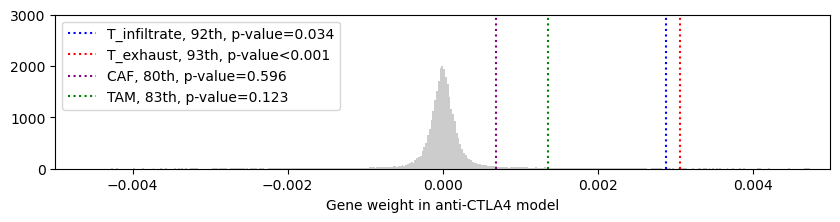

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

# weights=get_gene_persentile(model,CAF,mapp,genes,'../tem/','Gide_bsp_TCGAtrans_randParam_','va_f1')[1]
weights=get_gene_persentile(model,CAF,mapp,genes,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[1]
plt.figure(figsize=(10, 2), dpi=100)
# plt.axvline(x = 0.00811691750306636, color = 'b',ls=":",label='T_infiltrate, 92th, p-value=0.04')
# plt.axvline(x = 0.007156670794750054, color = 'r',ls=":",label='T_exhaust, 93th, p-value<0.001')
# plt.axvline(x = 0.005454109667334705, color = 'purple',ls=":",label='CAF, 88th, p-value=0.565')
# plt.axvline(x = 0.0031833139512505463, color = 'green',ls=":",label='TAM, 83th, p-value=0.117')
plt.axvline(x = 0.0028853092909412225, color = 'b',ls=":",label='T_infiltrate, 92th, p-value=0.034')
plt.axvline(x = 0.003063730142360378, color = 'r',ls=":",label='T_exhaust, 93th, p-value<0.001')
plt.axvline(x = 0.000686146005500632, color = 'purple',ls=":",label='CAF, 80th, p-value=0.596')
plt.axvline(x = 0.001355107686269828, color = 'green',ls=":",label='TAM, 83th, p-value=0.123')
plt.legend(loc="best")
plt.xlabel("Gene weight in anti-CTLA4 model")

sns.distplot(weights,bins=2000, hist = True, kde = False,
                 kde_kws = {'linewidth': 2},color='grey'
                )

# plt.ylim(0, 2000)
# plt.xlim(-0.015, 0.015)
plt.ylim(0, 3000)
plt.xlim(-0.005, 0.005)
# plt.show()
plt.savefig('CTLA4_percentile.png',dpi=200)

In [142]:
# gene importance
# Liu PD1
T_infiltrate="CD8A:CD8B:GZMA:GZMB:PRF1".split(':')
T_exhaust="HSPA1B:HSPA1A:NR4A2:RGS1:TNFAIP3:CAMK2N1:DUSP1:NR4A3:IFIT3:IFIT1B:FOSB:CCL5:SAMD3:CCL3L3:MACC1:VPS37B:TF:DSEL:SPATA20:ADSSL1:DHX58:SPP1:TRIM15:DUSP26:ABI3:SFN:C1QC:RTP4:JUN:BCKDHB:CCL4:POU6F1:CYSLTR2:SLC14A1:RGS16:CUEDC1:DEDD2:CPEB1:CTSS:TMEM88:FAM196B:SKI:BTG1:SYCP2L:RGS2:ABCB1:ADRB2:CD69:RNF166:TNN".split(':')
CAF="FAP:ACTA2:MFAP5:COL11A1:TN-C".split(':')
TAM="F13A1:FCER1A:CCL17:FOXQ1:ESPNL:CD1A:GATM:CCL13:PALLD:GALNT18:MAOA:RAMP1:STAB1:CCL26:CCL23:PARM1:CD1E:ITM2C:CALCRL:CRH:RGS18:MS4A6A:DHRS2:PON2:ALOX15:RAB33A:MOCOS:CCL18:IL17RB:FABP4:CMTM8:QPRT:CDR2L:DUOXA1:ABCC4:SYT17:PPP1R14A:PDGFC:GPT:FAM189A2:RASAL1:IPCEF1:ZNF366:MAP4K1:RAB30:PCED1B:TMIGD3:SH3BP4:RRS1:RNASE1".split(':')


# p_mean=get_gene_persentile(model,T_infiltrate,mapp,genes,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1')
p_mean=get_gene_persentile(model,T_infiltrate,mapp,genes,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
print(np.mean(p_mean[0]))
print(np.mean(p_mean[2]))

# p_mean=get_gene_persentile(model,T_exhaust,mapp,genes,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1')
p_mean=get_gene_persentile(model,T_exhaust,mapp,genes,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
print(np.mean(p_mean[0]))
print(np.mean(p_mean[2]))

# p_mean=get_gene_persentile(model,CAF,mapp,genes,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1')
p_mean=get_gene_persentile(model,CAF,mapp,genes,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
print(np.mean(p_mean[0]))
print(np.mean(p_mean[2]))

# p_mean=get_gene_persentile(model,TAM,mapp,genes,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1')
p_mean=get_gene_persentile(model,TAM,mapp,genes,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
print(np.mean(p_mean[0]))
print(np.mean(p_mean[2]))


####
print("random")
percentile_list=[]
for i in range(200):
    rd_p=cal_gp(model,T_infiltrate,mapp,genes,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    percentile_list.append(np.mean(rd_p[0]))
print(sum(np.array(percentile_list)>=87.811)/len(percentile_list))

percentile_list=[]
for i in range(200):
    rd_p=cal_gp(model,T_exhaust,mapp,genes,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    percentile_list.append(np.mean(rd_p[0]))
print(sum(np.array(percentile_list)>=86.443685)/len(percentile_list))

percentile_list=[]
for i in range(200):
    rd_p=cal_gp(model,CAF,mapp,genes,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    percentile_list.append(np.mean(rd_p[0]))
print(sum(np.array(percentile_list)>=97.4645764)/len(percentile_list))

percentile_list=[]
for i in range(200):
    rd_p=cal_gp(model,TAM,mapp,genes,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    percentile_list.append(np.mean(rd_p[0]))
print(sum(np.array(percentile_list)>=85.33568)/len(percentile_list))

87.81127524871872
0.0006068068914464675
86.44368516843646
0.001804224658573932
97.46457642447996
0.0026412742721731775
85.33568330975626
0.0015012924499737542
random
0.175
0.01
0.0
0.025


C:\Users\yjm85\Anaconda3\envs\Immunotherapy4\lib\site-packages\ipykernel_launcher.py:19: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



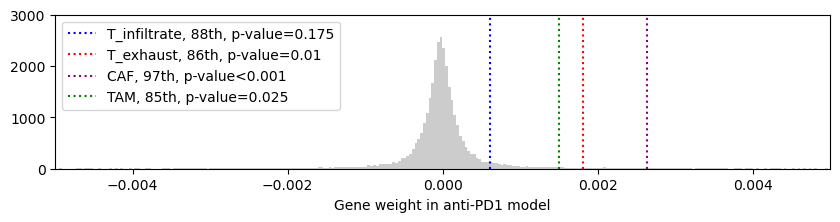

In [179]:
import matplotlib.pyplot as plt
import seaborn as sns

# weights=get_gene_persentile(model,CAF,mapp,genes,'../tem/','Liu_bsp_TCGAtrans_randParam_','va_f1')[1]
weights=get_gene_persentile(model,CAF,mapp,genes,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[1]
plt.figure(figsize=(10, 2), dpi=100)
# plt.axvline(x = 0.001340230918940506, color = 'b',ls=":",label='T_infiltrate, 88th, p-value=0.185')
# plt.axvline(x = 0.003941740140261472, color = 'r',ls=":",label='T_exhaust, 86th, p-value=0.01')
# plt.axvline(x = 0.004505266378328088, color = 'purple',ls=":",label='CAF, 97th, p-value<0.001')
# plt.axvline(x = 0.0019489156497701728, color = 'green',ls=":",label='TAM, 85th, p-value=0.05')
plt.axvline(x = 0.0006068068914464675, color = 'b',ls=":",label='T_infiltrate, 88th, p-value=0.175')
plt.axvline(x = 0.001804224658573932, color = 'r',ls=":",label='T_exhaust, 86th, p-value=0.01')
plt.axvline(x = 0.0026412742721731775, color = 'purple',ls=":",label='CAF, 97th, p-value<0.001')
plt.axvline(x = 0.0015012924499737542, color = 'green',ls=":",label='TAM, 85th, p-value=0.025')
plt.legend(loc="best")
plt.xlabel("Gene weight in anti-PD1 model")

sns.distplot(weights,bins=2000, hist = True, kde = False,
                 kde_kws = {'linewidth': 2},color='grey'
                )

# plt.ylim(0, 2000)
# plt.xlim(-0.015, 0.015)
plt.ylim(0, 3000)
plt.xlim(-0.005, 0.005)
# plt.show()
plt.savefig('PD1_percentile.png',dpi=200)

In [143]:
# gene importance
# IMvigor PDl1
T_infiltrate="CD8A:CD8B:GZMA:GZMB:PRF1".split(':')
T_exhaust="HSPA1B:HSPA1A:NR4A2:RGS1:TNFAIP3:CAMK2N1:DUSP1:NR4A3:IFIT3:IFIT1B:FOSB:CCL5:SAMD3:CCL3L3:MACC1:VPS37B:TF:DSEL:SPATA20:ADSSL1:DHX58:SPP1:TRIM15:DUSP26:ABI3:SFN:C1QC:RTP4:JUN:BCKDHB:CCL4:POU6F1:CYSLTR2:SLC14A1:RGS16:CUEDC1:DEDD2:CPEB1:CTSS:TMEM88:FAM196B:SKI:BTG1:SYCP2L:RGS2:ABCB1:ADRB2:CD69:RNF166:TNN".split(':')
CAF="FAP:ACTA2:MFAP5:COL11A1:TN-C".split(':')
TAM="F13A1:FCER1A:CCL17:FOXQ1:ESPNL:CD1A:GATM:CCL13:PALLD:GALNT18:MAOA:RAMP1:STAB1:CCL26:CCL23:PARM1:CD1E:ITM2C:CALCRL:CRH:RGS18:MS4A6A:DHRS2:PON2:ALOX15:RAB33A:MOCOS:CCL18:IL17RB:FABP4:CMTM8:QPRT:CDR2L:DUOXA1:ABCC4:SYT17:PPP1R14A:PDGFC:GPT:FAM189A2:RASAL1:IPCEF1:ZNF366:MAP4K1:RAB30:PCED1B:TMIGD3:SH3BP4:RRS1:RNASE1".split(':')


# p_mean=get_gene_persentile(model,T_infiltrate,mapp,genes,'../tem/','IMvigor_bsp_TCGAtrans_randParam_','va_f1')
p_mean=get_gene_persentile(model,T_infiltrate,mapp,genes,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
print(np.mean(p_mean[0]))
print(np.mean(p_mean[2]))

# p_mean=get_gene_persentile(model,T_exhaust,mapp,genes,'../tem/','IMvigor_bsp_TCGAtrans_randParam_','va_f1')
p_mean=get_gene_persentile(model,T_exhaust,mapp,genes,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
print(np.mean(p_mean[0]))
print(np.mean(p_mean[2]))

# p_mean=get_gene_persentile(model,CAF,mapp,genes,'../tem/','IMvigor_bsp_TCGAtrans_randParam_','va_f1')
p_mean=get_gene_persentile(model,CAF,mapp,genes,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
print(np.mean(p_mean[0]))
print(np.mean(p_mean[2]))

# p_mean=get_gene_persentile(model,TAM,mapp,genes,'../tem/','IMvigor_bsp_TCGAtrans_randParam_','va_f1')
p_mean=get_gene_persentile(model,TAM,mapp,genes,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
print(np.mean(p_mean[0]))
print(np.mean(p_mean[2]))


####
print("random")
percentile_list=[]
for i in range(200):
    rd_p=cal_gp(model,T_infiltrate,mapp,genes,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    percentile_list.append(np.mean(rd_p[0]))
print(sum(np.array(percentile_list)>=93.793789)/len(percentile_list))

percentile_list=[]
for i in range(200):
    rd_p=cal_gp(model,T_exhaust,mapp,genes,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    percentile_list.append(np.mean(rd_p[0]))
print(sum(np.array(percentile_list)>=88.8)/len(percentile_list))

percentile_list=[]
for i in range(200):
    rd_p=cal_gp(model,CAF,mapp,genes,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    percentile_list.append(np.mean(rd_p[0]))
print(sum(np.array(percentile_list)>=99.0835)/len(percentile_list))

percentile_list=[]
for i in range(200):
    rd_p=cal_gp(model,TAM,mapp,genes,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')
    percentile_list.append(np.mean(rd_p[0]))
print(sum(np.array(percentile_list)>=85.1499)/len(percentile_list))

93.79378956888755
0.0011054419033098384
88.80235375562478
0.001908977279304559
99.08350919505577
0.004500045813620091
85.14992694974606
0.0012651184317930453
random
0.01
0.0
0.0
0.03


C:\Users\yjm85\Anaconda3\envs\Immunotherapy4\lib\site-packages\ipykernel_launcher.py:19: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



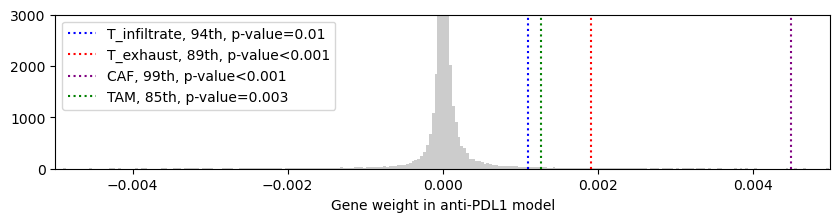

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns

# weights=get_gene_persentile(model,CAF,mapp,genes,'../tem/','IMvigor_bsp_TCGAtrans_randParam_','va_f1')[1]
weights=get_gene_persentile(model,CAF,mapp,genes,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')[1]
plt.figure(figsize=(10, 2), dpi=100)
# plt.axvline(x = 0.003902047219453379, color = 'b',ls=":",label='T_infiltrate, 94th, p-value=0.01')
# plt.axvline(x = 0.004179705977026903, color = 'r',ls=":",label='T_exhaust, 89th, p-value<0.001')
# plt.axvline(x = 0.004053490734077059, color = 'purple',ls=":",label='CAF, 99th, p-value<0.001')
# plt.axvline(x = 0.003440552429590472, color = 'green',ls=":",label='TAM, 85th, p-value=0.005')
plt.axvline(x = 0.0011054419033098384, color = 'b',ls=":",label='T_infiltrate, 94th, p-value=0.01')
plt.axvline(x = 0.001908977279304559, color = 'r',ls=":",label='T_exhaust, 89th, p-value<0.001')
plt.axvline(x = 0.004500045813620091, color = 'purple',ls=":",label='CAF, 99th, p-value<0.001')
plt.axvline(x = 0.0012651184317930453, color = 'green',ls=":",label='TAM, 85th, p-value=0.003')
plt.legend(loc="best")
plt.xlabel("Gene weight in anti-PDL1 model")

sns.distplot(weights,bins=2000, hist = True, kde = False,
                 kde_kws = {'linewidth': 3},color='grey'
                )

plt.ylim(0, 3000)
plt.xlim(-0.005, 0.005)
# plt.show()
plt.savefig('PDL1_percentile.png',dpi=200)

In [150]:
p_mean

([96.14410611998794,
  77.82936388302683,
  85.28489599035272,
  90.55170334639735,
  99.82212842930359,
  92.20982815797407,
  82.90021103406693,
  96.20440156768164,
  80.37383177570094,
  93.77449502562557,
  98.15194452818812,
  97.86252637925837,
  74.87488694603557,
  91.8842327404281,
  81.91438046427494,
  99.34277962013869,
  81.96864636719928,
  73.62677117877601,
  73.63280072354537,
  65.6104914078987,
  96.85257763038891,
  82.79770877298763,
  98.96593307205306,
  92.00783840820019,
  84.53723243895087,
  67.74796502864034],
 array([-1.03283594e-03, -2.87159298e-04, -6.47830066e-05, ...,
         1.63050378e-03,  9.67260858e-06,  2.06697188e-03]))

In [86]:
## Bayesian network
##################################
ptnum2OS={}
ptnum2Event={}
pt2num={}
ptnum2Res={}
fclinic=open("./tide_data/Gide/clinic.txt")
fpd1=open("./tide_data/Gide2019_PD1_Melanoma_RNASeq/Gide2019_PD1_Melanoma_RNASeq/ICB.Gide2019_Pembrolizumab-Nivolumab_Melanoma.clinical")
fpd1ctla4=open("./tide_data/Gide2019_PD1+CTLA4_Melanoma_RNASeq/Gide2019_PD1+CTLA4_Melanoma_RNASeq/ICB.Gide2019_Pembrolizumab-Nivolumab+Ipilimumab_Melanoma.clinical")
line=fpd1ctla4.readline()
lines=fpd1ctla4.readlines()
for i in lines:
    ptnum="ipiPD1_"+i.split('\t')[0]
    OS=i.split('\t')[1]
    Event=i.split('\t')[2]
    Res = i.split('\t')[10]
    ptnum2OS[ptnum]=OS
    ptnum2Event[ptnum]=Event
    ptnum2Res[ptnum]=Res
line=fpd1.readline()
lines=fpd1.readlines()
for i in lines:
    ptnum="PD1_"+i.split('\t')[0]
    OS=i.split('\t')[1]
    Event=i.split('\t')[2]
    Res = i.split('\t')[10]
    ptnum2OS[ptnum]=OS
    ptnum2Event[ptnum]=Event
    ptnum2Res[ptnum]=Res
line=fclinic.readline()
lines=fclinic.readlines()
for i in lines:
    pt=i.split('\t')[0]
    num=i.split('\t')[2][:-5]
    pt2num[pt]=num



result=[]
f=open("./tide_data/Gide/survival.txt",'w')
for i in range(5):
    info=result_info[i]
    pred=np.array(result_pred[i])[:,1]
    for j in range(info.shape[0]):
        # print(pred[j])
        pt=info[j].split('_')[3]
        num=pt2num[pt]
        p=pred[j]>=0.5
        OS=float(ptnum2OS[num])
        Res = ptnum2Res[num]
        # print(Res)
        if Res == "PD" or Res == "SD":
            Res = 0
        else:
            Res = 1
        # print(Res)
        event=ptnum2Event[num]=='1'
        tem=[]
        tem.append(pt)
        tem.append(p)
        tem.append(pred[j])
        tem.append(OS)
        tem.append(event)
        tem.append(Res)
        result.append(tem)
        

import pandas as pd
df = pd.DataFrame(result, columns=['pt','prediction','pred_value','OS','event',"Res"])
df

,pt,prediction,pred_value,OS,event,Res
0,ERR2208945,True,0.559563,897.0,True,1
1,ERR2208951,True,0.598852,878.0,True,1
2,ERR2208916,True,0.503558,650.0,False,1
3,ERR2208900,True,0.503398,410.0,False,1
4,ERR2208899,True,0.575141,538.0,False,0
...,...,...,...,...,...,...
86,ERR3262564,False,0.490894,22.0,True,0
87,ERR2208974,True,0.872954,80.0,True,0
88,ERR2208892,True,0.846457,357.0,True,1
89,ERR2208911,True,0.812880,627.0,False,1


In [107]:
from pgmpy.models import BayesianModel
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
import numpy as np

# Sample data for X and Y
import statistics
med = statistics.median(df.loc[:,'OS'])

data = pd.DataFrame({
    'X': df.loc[:,'Res'],
    'Y': df.loc[:,'OS'] > med
})

# Construct a Bayesian network
model = BayesianModel([('X', 'Y')])

# Estimate parameters using Maximum Likelihood Estimation
model.fit(data, estimator=MaximumLikelihoodEstimator)

# Create an inference object
inference = VariableElimination(model)

# Perform inference
query_result = inference.query(variables=['Y'], evidence={'X': 0})
print("X is 0:")
print(query_result)

query_result = inference.query(variables=['Y'], evidence={'X': 1})
print("X is 1:")
print(query_result)

X is 0:
+----------+----------+
| Y        |   phi(Y) |
+==========+==========+
| Y(False) |   0.7619 |
+----------+----------+
| Y(True)  |   0.2381 |
+----------+----------+
X is 1:
+----------+----------+
| Y        |   phi(Y) |
+==========+==========+
| Y(False) |   0.2857 |
+----------+----------+
| Y(True)  |   0.7143 |
+----------+----------+


In [112]:
## Variance
###################
import numpy as np

Gide_IRnet = [0.664, 0.941, 0.856, 0.648, 0.536]
Gide_NetBio = [0.692, 0.794, 0.571, 0.330, 0.563]

print("Gide:")
print(np.var(Gide_IRnet))
print(np.var(Gide_NetBio))

Liu_IRnet = [0.648, 0.627, 0.457, 0.687, 0.702]
Liu_NetBio = [0.659, 0.598, 0.550, 0.563 ,0.580]

print("Liu:")
print(np.var(Liu_IRnet))
print(np.var(Liu_NetBio))

# Tide=[0.312,0.411,0.514,0.719,0.478,0.716]
Tide=[0.312,0.411,0.514,0.719,0.716]
print(np.var(Tide))

Gide:
0.02182159999999999
0.024142000000000004
Liu:
0.007705359999999999
0.0014508000000000008
0.026432239999999996


In [187]:
g=list(genes)
#ctla4
# p_mean=get_gene_persentile(model,g,mapp,genes,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')

# #PD1    
# p_mean=get_gene_persentile(model,g,mapp,genes,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')

    
# #pdl1
p_mean=get_gene_persentile(model,g,mapp,genes,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1')

    
weights = p_mean[2]
percentile = p_mean[0]


In [188]:
df=pd.DataFrame({"genes":g, "weights":weights, "percentile":percentile})
df.to_csv('gene_percentile_pdl1.csv', index=False)

In [189]:
df

,genes,weights,percentile
0,AKR1A1,0.000843,95.492915
1,ADH1A,0.000111,84.871872
2,ADH1B,0.000857,96.409406
3,ADH1C,0.007509,99.599035
4,ADH4,0.000551,93.901115
...,...,...,...
8075,EIF4G1,0.000816,96.300874
8076,EIF4G2,0.003604,99.083509
8077,EIF4G3,0.000051,66.225505
8078,MIB2,0.000254,91.878203


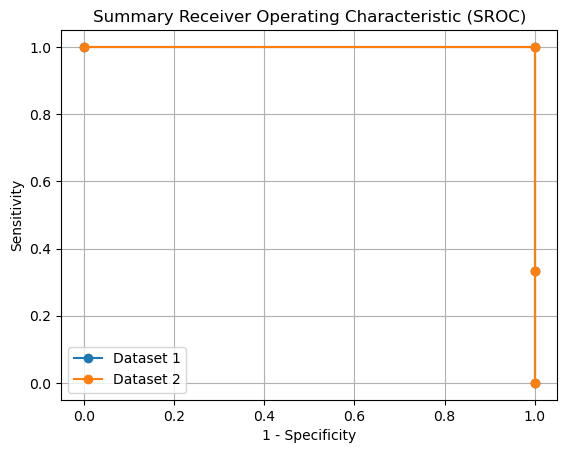

AUC for Dataset 1: 1.0
AUC for Dataset 2: 1.0


In [190]:
#SROC
#############
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def calculate_sroc(ground_truth, predicted_scores):
    fpr, tpr, thresholds = roc_curve(ground_truth, predicted_scores)
    auc = roc_auc_score(ground_truth, predicted_scores)
    sroc_curve = 1 - fpr, tpr
    return sroc_curve, auc

# Example data for two datasets
ground_truth_dataset1 = np.array([0, 1, 1, 0, 1, 0])
predicted_scores_dataset1 = np.array([0.2, 0.7, 0.9, 0.4, 0.6, 0.1])

ground_truth_dataset2 = np.array([0, 1, 1, 0, 0, 1])
predicted_scores_dataset2 = np.array([0.3, 0.6, 0.8, 0.2, 0.1, 0.9])

# Calculate SROC for each dataset
sroc_curve_dataset1, auc_dataset1 = calculate_sroc(ground_truth_dataset1, predicted_scores_dataset1)
sroc_curve_dataset2, auc_dataset2 = calculate_sroc(ground_truth_dataset2, predicted_scores_dataset2)

# Plot SROC curve for each dataset
plt.figure()
plt.plot(sroc_curve_dataset1[0], sroc_curve_dataset1[1], marker='o', label='Dataset 1')
plt.plot(sroc_curve_dataset2[0], sroc_curve_dataset2[1], marker='o', label='Dataset 2')
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('Summary Receiver Operating Characteristic (SROC)')
plt.legend()
plt.grid(True)
plt.show()

print(f'AUC for Dataset 1: {auc_dataset1}')
print(f'AUC for Dataset 2: {auc_dataset2}')


In [195]:
mapp, genes, pathways = get_KEGG_map(genes, filename='./Kegg/human_KeggPathwayGene.gmt')
n_genes, n_pathways = mapp.shape



def build_model(mapp, n_genes, n_pathways, mapping_l1_reg = 2.5e-3, gat1_l2_reg = 2.5e-3, gat2_l2_reg = 2.5e-3, pool_l1_reg = 2.5e-3, x_dropRate = 0.3, 
                gat1_dropRate = 0.3, gat2_dropRate = 0.3, gat1_channel = 3, gat1_nhead = 3, gat2_channel = 6, pool_channel = 12, dense_channel = 6):
    x_in = Input(shape=(n_genes,))
    x_drop1 = Dropout(x_dropRate)(x_in)
    mapping_layer = SparseTF(n_pathways, mapp, activation='elu', W_regularizer=L1(mapping_l1_reg),
                                name='mapping', kernel_initializer='glorot_uniform',
                                use_bias=True)
    layer2_output = mapping_layer(x_drop1)
    layer2_res=Reshape([n_pathways,1])(layer2_output)
    a_in = Input(shape=(n_pathways,),sparse=True)
    x_1 = GATConv(
        gat1_channel,
        attn_heads=gat1_nhead,
        concat_heads=False,
        activation="tanh",
        return_attn_coef=False,
        dropout_rate=gat1_dropRate,
        kernel_regularizer=l2(gat1_l2_reg),
        attn_kernel_regularizer=l2(gat1_l2_reg),
        bias_regularizer=l2(gat1_l2_reg),
        bias_initializer='glorot_uniform',
    )([layer2_res, a_in])
    x1bn = layers.BatchNormalization()(x_1)
    x_2,att = GATConv(
        gat2_channel,
        attn_heads=1,
        concat_heads=True,
        activation="tanh",
        return_attn_coef=True,
        dropout_rate=gat2_dropRate,
        kernel_regularizer=l2(gat2_l2_reg),
        attn_kernel_regularizer=l2(gat2_l2_reg),
        bias_regularizer=l2(gat2_l2_reg),
        bias_initializer='glorot_uniform',
    )([x1bn, a_in])
    x2bn = layers.BatchNormalization()(x_2)
    attpool=GlobalAttentionPool(pool_channel, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=L1(pool_l1_reg))(x2bn)
    x_fc1 = Dense(dense_channel, activation="elu")(attpool)
    output = Dense(2, activation="softmax")(x_fc1)  # MNIST has 10 classes
    model = Model(inputs=[x_in, a_in], outputs=output)
    #optimizer = Adam(lr=1e-1)
    return model



mapping_l1_reg = 2.5e-3
gat1_l2_reg = 2.5e-3
gat2_l2_reg = 2.5e-3
pool_l1_reg = 2.5e-3
x_dropRate = 0.3
gat1_dropRate = 0.3
gat2_dropRate = 0.3
gat1_channel = 3
gat1_nhead = 3
gat2_channel = 6
pool_channel = 12
dense_channel = 6


model=build_model(mapp, n_genes, n_pathways, mapping_l1_reg = 2.5e-3, gat1_l2_reg = 2.5e-3, gat2_l2_reg = 2.5e-3, pool_l1_reg = 2.5e-3, x_dropRate = 0.3, 
                gat1_dropRate = 0.3, gat2_dropRate = 0.3, gat1_channel = 3, gat1_nhead = 3, gat2_channel = 6, pool_channel = 12, dense_channel = 6)



#model.summary()

[ 9. 10.]
load weights from Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_0/_va_f1
load weights from Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_0/_va_f1
[ 8. 10.]
load weights from Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_1/_va_f1
load weights from Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_1/_va_f1
[ 8. 10.]
load weights from Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_2/_va_f1
load weights from Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_2/_va_f1
[ 8. 10.]
load weights from Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_3/_va_f1
load weights from Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_3/_va_f1
[9. 9.]
load weights from Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_4/_va_f1
load weights from Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_4/_va_f1
[14. 10.]
load weights from Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_0/_va_f1
load weights from L

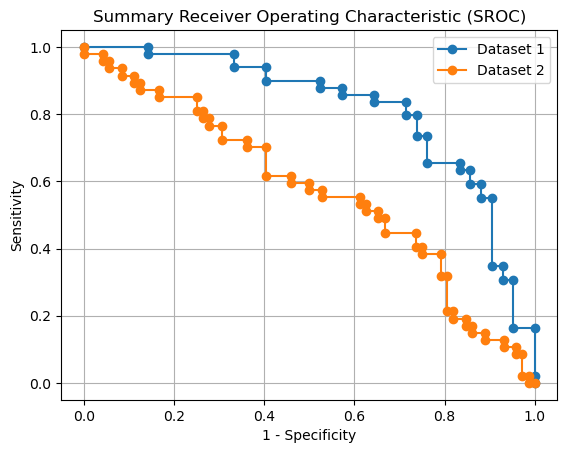

AUC for Dataset 1: 0.814868804664723
AUC for Dataset 2: 0.5691489361702127


In [197]:
# within study evaluation

from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
import numpy as np
import sklearn
import random
random.seed(996)


###  random parameter  ###
mapping_l1_reg = 2.5e-3
gat1_l2_reg = 2.5e-3
gat2_l2_reg = 2.5e-3
pool_l1_reg = 2.5e-3
x_dropRate = 0.5
gat1_dropRate = 0.4
gat2_dropRate = 0.4
gat1_channel = 4
gat1_nhead = 4
gat2_channel = 4
pool_channel = 8
dense_channel = 8
batch_size = 10  # Batch size
hyperParams_random = np.array([
[2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.5,0.4,0.4,4,4,4,8,8,10],
[2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.5,0.4,0.4,4,4,4,8,8,10],
[2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.5,0.4,0.4,4,4,4,8,8,10],
[2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.5,0.4,0.4,4,4,4,8,8,10],
[2.5e-3,2.5e-3,2.5e-3,2.5e-3,0.5,0.4,0.4,4,4,4,8,8,10]
])


###  opti IMvigor ROC  ###
hyperParams_IMvigor=np.array([
[0.00675190391336071,0.005493762552723812,0.004519753059018278,0.0045195975667924534,0.46362793709225414,0.48819564127373993,0.2649679082634909,7,9,5,25,11,9],
[0.004753781661814064,0.00984774073557786,0.0048767374957450465,0.0007873736162618307,0.3194759952137326,0.30398181418512144,0.4979219375485108,3,3,10,12,9,5],
[0.0071387418189729525,0.005222498035643917,0.0027004909388650775,0.0009363385112361626,0.29024065711708774,0.14865279095047879,0.15748988511469506,3,6,6,18,13,6],
[0.003968517903566386,0.004080120823919732,0.0042587618179442885,0.009978974683794863,0.20088388535107163,0.3332139513019352,0.10333163146773422,4,4,12,5,5,3],
[0.0018638222878056294,0.0029886076626495254,0.0040239676839539254,0.003992625256227416,0.18392455882921968,0.23979599005221788,0.2249788516873279,3,5,15,13,7,4]
])

###  opti Liu ROC  ###
hyperParams_Liu=np.array([
[0.009161283552587185,0.0086139933888295,0.0010692657989040144,0.003913069210703885,0.3748124481558166,0.49048942098340775,0.4925881321925005,4.0,9.0,8.0,14.0,14.0,3],
[0.009161283552587185,0.0086139933888295,0.0010692657989040144,0.003913069210703885,0.3748124481558166,0.49048942098340775,0.4925881321925005,4.0,9.0,8.0,14.0,14.0,3],
[0.009161283552587185,0.0086139933888295,0.0010692657989040144,0.003913069210703885,0.3748124481558166,0.49048942098340775,0.4925881321925005,4.0,9.0,8.0,14.0,14.0,3],
[0.009161283552587185,0.0086139933888295,0.0010692657989040144,0.003913069210703885,0.3748124481558166,0.49048942098340775,0.4925881321925005,4.0,9.0,8.0,14.0,14.0,3],
[0.009161283552587185,0.0086139933888295,0.0010692657989040144,0.003913069210703885,0.3748124481558166,0.49048942098340775,0.4925881321925005,4.0,9.0,8.0,14.0,14.0,3]
])



model=build_model(mapp, n_genes, n_pathways, mapping_l1_reg, gat1_l2_reg, gat2_l2_reg, pool_l1_reg, x_dropRate, 
                    gat1_dropRate, gat2_dropRate, gat1_channel, gat1_nhead, gat2_channel, pool_channel, dense_channel)


def get_scores(datafromnpz,weight_folder,weight_presuffix,weight_metric,cutoff,hyper):
    random.seed(996)
    ind=[]
    for i in range(len(datafromnpz['info'])):
        ind.append(i)
    rind=random.sample(ind,len(ind))
    rx=datafromnpz['x'][rind]
    ry=datafromnpz['y'][rind]
    rinfo=datafromnpz['info'][rind]
    
    allfold_ROCauc=[]
    allfold_f1=[]
    allfold_acc=[]
    y_vec=[]
    x_vec=[]
    random.seed(996)
    skf = StratifiedKFold(n_splits=5)
    fold=0
    y_binary = ry[:,1]
    for train, test in skf.split(rx,y_binary):
            #print('fold '+str(fold)+' : ')
            #print("%s" % (test))
            x=rx[test]
            y=ry[test]
            #x=rx[train]
            #y=ry[train]
            info=rinfo[test]
            cols=datafromnpz['cols']
            a=datafromnpz['pathway_a']
            #print("%s" % (info))
            #print("%s" % (y[:,1]))
            print(sum(y))
            if hyper=='IMvigor':
                hyperParams=hyperParams_IMvigor
            if hyper=='random':
                hyperParams=hyperParams_random
            if hyper=='Liu':
                hyperParams=hyperParams_Liu
            
            [mapping_l1_reg, gat1_l2_reg, gat2_l2_reg, pool_l1_reg, x_dropRate, gat1_dropRate, 
             gat2_dropRate, gat1_channel, gat1_nhead, gat2_channel, pool_channel, dense_channel]=hyperParams[fold,:-1]
            #print('hyper-parameters:')
            #for i in [mapping_l1_reg, gat1_l2_reg, gat2_l2_reg, pool_l1_reg, x_dropRate, gat1_dropRate, 
            #          gat2_dropRate, gat1_channel, gat1_nhead, gat2_channel, pool_channel, dense_channel]:
            #    print(i)
            model=build_model(mapp, n_genes, n_pathways, mapping_l1_reg, gat1_l2_reg, gat2_l2_reg, pool_l1_reg, x_dropRate, 
                              gat1_dropRate, gat2_dropRate, int(gat1_channel), int(gat1_nhead), int(gat2_channel), int(pool_channel), int(dense_channel))
            
            results=np.zeros([1,y.shape[0],y.shape[1]])
            #for weight_metric in ['tr_f1','tr_f1']:
            #for weight_metric in ['tr_ROCauc','tr_ROCauc']:
            for weight_metric in ['va_f1','va_f1']:
            #for weight_metric in ['va_ROCauc','va_ROCauc']:
            #for weight_metric in ['te_loss','te_loss']:
                print("load weights from "+weight_presuffix+str(fold)+'/_'+weight_metric)
                model.load_weights(weight_folder+weight_presuffix+str(fold)+'/_'+weight_metric)
                predictions = model([x,a],training=False)
                results+=predictions
            
            results_mean = np.mean(results, axis=0)/2
            y_vec.extend(y[:,1])
            x_vec.extend(results_mean[:,1])
            fold+=1
    return [y_vec, x_vec]
        




random.seed(996)
cutoff=0.5

random.seed(996)
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Gide_zscore.npz')
[y_vec_gide, x_vec_gide] = get_scores(datafromnpz,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff,'random')

random.seed(996)
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Liu_zscore.npz')
[y_vec_liu, x_vec_liu] = get_scores(datafromnpz,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff,'random')

random.seed(996)
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Kim_zscore.npz')
[y_vec_kim, x_vec_kim] = get_scores(datafromnpz,'./weights_counts_zscore_focaloss_val/','Kim_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval4_','va_f1',cutoff,'random')

random.seed(996)
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_IMvigor_zscore.npz')
[y_vec_imvigor, x_vec_imvigor] = get_scores(datafromnpz,'./weights_counts_zscore_focaloss_val/','IMvigor_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff,'random')




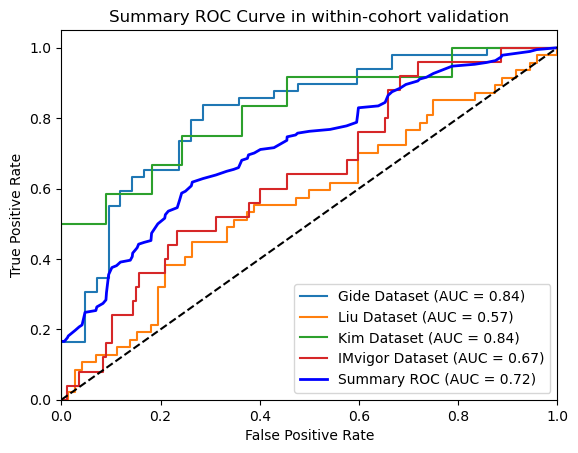

In [202]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import statsmodels.api as sm

# Function to calculate ROC and AUC
def calculate_roc_auc(y_true, y_pred):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

# Sample data (replace these with your actual ground truth and predictions)
datasets = {
    'Gide Dataset': (y_vec_gide, x_vec_gide, 0.84),
    'Liu Dataset': (y_vec_liu, x_vec_liu, 0.57),
    'Kim Dataset': (y_vec_kim, x_vec_kim, 0.84),
    'IMvigor Dataset': (y_vec_imvigor, x_vec_imvigor, 0.67)
}

# Plotting SROC
plt.figure()

for label, (y_true, y_pred, score) in datasets.items():
    fpr, tpr, roc_auc = calculate_roc_auc(y_true, y_pred)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {score:.2f})')

# Summary ROC curve (average of individual ROC curves)
all_fpr = np.unique(np.concatenate([roc_curve(y_true, y_pred)[0] for y_true, y_pred, score in datasets.values()]))
mean_tpr = np.zeros_like(all_fpr)

for y_true, y_pred, score in datasets.values():
    mean_tpr += np.interp(all_fpr, *roc_curve(y_true, y_pred)[:2])

mean_tpr /= len(datasets)
mean_auc = auc(all_fpr, mean_tpr)

plt.plot(all_fpr, mean_tpr, color='blue', label=f'Summary ROC (AUC = {mean_auc:.2f})', linewidth=2)

# Plot diagonal
plt.plot([0, 1], [0, 1], 'k--')

# Plot settings
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Summary ROC Curve in within-cohort validation')
plt.legend(loc='lower right')
plt.show()


In [204]:
# cross study evaluation

from sklearn.model_selection import KFold
import numpy as np
import sklearn
import random
from random import choices
random.seed(996)


###  random parameter  ###
mapping_l1_reg = 2.5e-3
gat1_l2_reg = 2.5e-3
gat2_l2_reg = 2.5e-3
pool_l1_reg = 2.5e-3
x_dropRate = 0.5
gat1_dropRate = 0.4
gat2_dropRate = 0.4
gat1_channel = 4
gat1_nhead = 4
gat2_channel = 4
pool_channel = 8
dense_channel = 8
batch_size = 10  # Batch size

model=build_model(mapp, n_genes, n_pathways, mapping_l1_reg, gat1_l2_reg, gat2_l2_reg, pool_l1_reg, x_dropRate, 
                    gat1_dropRate, gat2_dropRate, gat1_channel, gat1_nhead, gat2_channel, pool_channel, dense_channel)



    

def get_scores(datafromnpz,weight_folder,weight_presuffix,weight_metric,cutoff):
            x=datafromnpz['x']
            y=datafromnpz['y']
            info=datafromnpz['info']
            cols=datafromnpz['cols']
            a=datafromnpz['pathway_a']
            # print("%s" % (info))
            #print("%s" % (y[:,1]))
            model.load_weights(weight_folder+weight_presuffix+'/_'+weight_metric)
            predictions = model([x,a],training=False)
            roc_auc_score=sklearn.metrics.roc_auc_score(y[:,1], predictions[:,1])
            acc=sklearn.metrics.accuracy_score(y[:,1], predictions[:,1]>cutoff)
            f1=sklearn.metrics.f1_score(y[:,1],predictions[:,1]>cutoff)
            #print("%s" % (predictions[:,1]>cutoff))
            print('roc_auc_score = '+str(roc_auc_score))
            print('acc = '+str(acc))
            print('f1 score = '+str(f1))
        
foldnum=5
def get_scores_ensemble(datafromnpz,weight_folder,weight_presuffix,weight_metric,cutoff):
            y_vec=[]
            x_vec=[]
            x=datafromnpz['x']
            y=datafromnpz['y']
            info=datafromnpz['info']
            cols=datafromnpz['cols']
            a=datafromnpz['pathway_a']
            # print("%s" % (info))
            #print("%s" % (y[:,1]))
            print(sum(y))
            results=np.zeros([foldnum,y.shape[0],y.shape[1]])
            #for weight_metric in ['tr_f1','va_f1']:
            #for weight_metric in ['tr_f1','tr_f1']:
            for weight_metric in ['va_f1','va_f1']:
            #for weight_metric in ['va_ROCauc','va_ROCauc']:
            #for weight_metric in ['va_ROCauc','va_f1']:
             for fold in range(0,foldnum):
                model.load_weights(weight_folder+weight_presuffix+str(fold)+'/_'+weight_metric)
                predictions = model([x,a],training=False)
                results[fold,:,:]+=predictions
            
            results_mean = np.mean(results, axis=0)/2
            y_vec.extend(y[:,1])
            x_vec.extend(results_mean[:,1])
            #print(results_mean)
            
            return [y_vec, x_vec]


    
    
    
cutoff=0.5    
# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Liu_zscore.npz') #SKCM (SKCM better tr)
# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz') #SKCM (merged better)
# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_IMvigor_zscore.npz') #BLCA (merge_boostp1 better)
# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Kim_zscore.npz') #STAD (SKCM better?)
# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Gide_zscore.npz') #SKCM (merged better)
# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Riaz_zscore.npz') #SKCM (merged better)


# [results, results_mean] = get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)
# [results, results_mean] = get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Liu_zscore.npz')
# [y_vec_liu, x_vec_liu]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
# [y_vec_auslander, x_vec_auslander]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_IMvigor_zscore.npz')
# [y_vec_imvigor, x_vec_imvigor]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Kim_zscore.npz')
# [y_vec_kim, x_vec_kim]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Riaz_zscore.npz')
# [y_vec_riaz, x_vec_riaz]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)




# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Gide_zscore.npz')
# [y_vec_gide, x_vec_gide]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
# [y_vec_auslander, x_vec_auslander]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_IMvigor_zscore.npz')
# [y_vec_imvigor, x_vec_imvigor]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Kim_zscore.npz')
# [y_vec_kim, x_vec_kim]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

# datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Riaz_zscore.npz')
# [y_vec_riaz, x_vec_riaz]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)



[72. 47.]
[34.  3.]
[167.  25.]
[33. 12.]
[39. 10.]


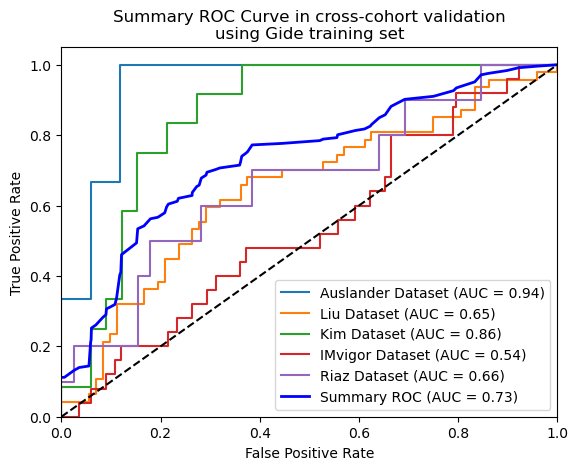

In [209]:
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Liu_zscore.npz')
[y_vec_liu, x_vec_liu]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
[y_vec_auslander, x_vec_auslander]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_IMvigor_zscore.npz')
[y_vec_imvigor, x_vec_imvigor]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Kim_zscore.npz')
[y_vec_kim, x_vec_kim]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Riaz_zscore.npz')
[y_vec_riaz, x_vec_riaz]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Gide_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import statsmodels.api as sm

# Function to calculate ROC and AUC
def calculate_roc_auc(y_true, y_pred):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

# Sample data (replace these with your actual ground truth and predictions)
datasets = {
    'Auslander Dataset': (y_vec_auslander, x_vec_auslander, 0.94),
    'Liu Dataset': (y_vec_liu, x_vec_liu, 0.65),
    'Kim Dataset': (y_vec_kim, x_vec_kim, 0.86),
    'IMvigor Dataset': (y_vec_imvigor, x_vec_imvigor, 0.54),
    'Riaz Dataset': (y_vec_riaz, x_vec_riaz, 0.66)
}

# Plotting SROC
plt.figure()

for label, (y_true, y_pred, score) in datasets.items():
    fpr, tpr, roc_auc = calculate_roc_auc(y_true, y_pred)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {score:.2f})')

# Summary ROC curve (average of individual ROC curves)
all_fpr = np.unique(np.concatenate([roc_curve(y_true, y_pred)[0] for y_true, y_pred, score in datasets.values()]))
mean_tpr = np.zeros_like(all_fpr)

for y_true, y_pred, score in datasets.values():
    mean_tpr += np.interp(all_fpr, *roc_curve(y_true, y_pred)[:2])

mean_tpr /= len(datasets)
mean_auc = auc(all_fpr, mean_tpr)

plt.plot(all_fpr, mean_tpr, color='blue', label=f'Summary ROC (AUC = {mean_auc:.2f})', linewidth=2)

# Plot diagonal
plt.plot([0, 1], [0, 1], 'k--')

# Plot settings
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Summary ROC Curve in cross-cohort validation\nusing Gide training set')
plt.legend(loc='lower right')
plt.show()


[42. 49.]
[34.  3.]
[167.  25.]
[33. 12.]
[39. 10.]


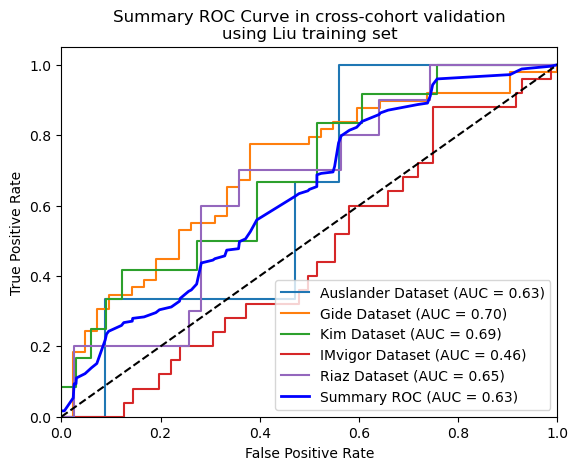

In [210]:
datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Gide_zscore.npz')
[y_vec_gide, x_vec_gide]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Auslander_zscore.npz')
[y_vec_auslander, x_vec_auslander]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_IMvigor_zscore.npz')
[y_vec_imvigor, x_vec_imvigor]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Kim_zscore.npz')
[y_vec_kim, x_vec_kim]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)

datafromnpz=np.load('immunotherapy_tide_onehotlabel_kegg_pathgraph_Riaz_zscore.npz')
[y_vec_riaz, x_vec_riaz]=get_scores_ensemble(datafromnpz,'./weights_counts_zscore_focaloss_val/','Liu_bsp_TCGAtransSKCMBLCASTADboostp1_bootstp3_2_steval5_','va_f1',cutoff)


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import statsmodels.api as sm

# Function to calculate ROC and AUC
def calculate_roc_auc(y_true, y_pred):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

# Sample data (replace these with your actual ground truth and predictions)
datasets = {
    'Auslander Dataset': (y_vec_auslander, x_vec_auslander, 0.63),
    'Gide Dataset': (y_vec_gide, x_vec_gide, 0.70),
    'Kim Dataset': (y_vec_kim, x_vec_kim, 0.69),
    'IMvigor Dataset': (y_vec_imvigor, x_vec_imvigor, 0.46),
    'Riaz Dataset': (y_vec_riaz, x_vec_riaz, 0.65)
}

# Plotting SROC
plt.figure()

for label, (y_true, y_pred, score) in datasets.items():
    fpr, tpr, roc_auc = calculate_roc_auc(y_true, y_pred)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {score:.2f})')

# Summary ROC curve (average of individual ROC curves)
all_fpr = np.unique(np.concatenate([roc_curve(y_true, y_pred)[0] for y_true, y_pred, score in datasets.values()]))
mean_tpr = np.zeros_like(all_fpr)

for y_true, y_pred, score in datasets.values():
    mean_tpr += np.interp(all_fpr, *roc_curve(y_true, y_pred)[:2])

mean_tpr /= len(datasets)
mean_auc = auc(all_fpr, mean_tpr)

plt.plot(all_fpr, mean_tpr, color='blue', label=f'Summary ROC (AUC = {mean_auc:.2f})', linewidth=2)

# Plot diagonal
plt.plot([0, 1], [0, 1], 'k--')

# Plot settings
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Summary ROC Curve in cross-cohort validation\nusing Liu training set')
plt.legend(loc='lower right')
plt.show()

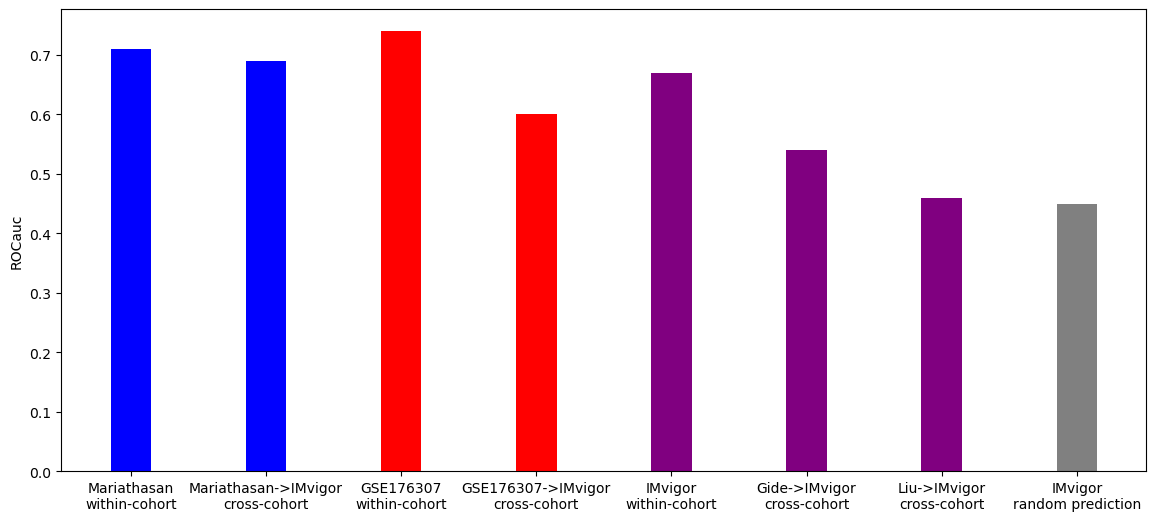

In [229]:
import matplotlib.pyplot as plt

# Sample data
heights = [0.71, 0.69, 0.74, 0.60, 0.67, 0.54, 0.46, 0.45]


# Create a list of indices for the x-axis
x = range(len(heights))

plt.figure(figsize=(14, 6))  # Width, Height in inches
# Create the bar plot
colors = ['blue', 'blue', 'red', 'red', "purple", "purple", "purple", 'grey'] 
plt.bar(["Mariathasan\nwithin-cohort","Mariathasan->IMvigor\ncross-cohort",
         "GSE176307\nwithin-cohort","GSE176307->IMvigor\ncross-cohort",
         "IMvigor\nwithin-cohort", "Gide->IMvigor\ncross-cohort", "Liu->IMvigor\ncross-cohort",
         "IMvigor\nrandom prediction"], heights, width=0.3, color= colors)

# Add labels and title

plt.ylabel('ROCauc')


# Show the plot
plt.show()
